In [1]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, precision_recall_curve, auc,r2_score, roc_auc_score,roc_curve,confusion_matrix,average_precision_score
import numpy as np
import sweetviz as sv
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor 
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier


C:\Users\ENTRA\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
directorio = "Analizadas"
rangos = [str(x) for x in range(32, 42) if x != 37 and x != 34]
dataframes = []

for numero in rangos:
    nombre_archivo = f'B2400{numero} Genotypes Table.txt'
    ruta_archivo = os.path.join(directorio, nombre_archivo)
    df = pd.read_csv(ruta_archivo, delimiter='\t', skiprows=range(1, 22))
    dataframes.append(df)

Analizadas = pd.concat(dataframes, ignore_index=True)

directorio = "Sin_Analizar"
dataframes = []
for numero in rangos:
    nombre_archivo = f'B2400{numero} sin analizar Genotypes Table.txt'
    ruta_archivo = os.path.join(directorio, nombre_archivo)
    df = pd.read_csv(ruta_archivo, delimiter='\t', skiprows=range(1, 22))
    dataframes.append(df)

NOAnalizadas = pd.concat(dataframes, ignore_index=True)


# DETECTOR

In [3]:
NOAnalizadas['Allele 1'] = NOAnalizadas['Allele 1'].replace({'X': 0, 'Y': 1,"?":np.nan})
NOAnalizadas['Allele 2'] = NOAnalizadas['Allele 2'].replace({'X': 0, 'Y': 1,"?":np.nan})
Analizadas['Allele 1'] = Analizadas['Allele 1'].replace({'X': 0, 'Y': 1})
Analizadas['Allele 2'] = Analizadas['Allele 2'].replace({'X': 0, 'Y': 1})

columnas_a_convertir = ['Allele 1', 'Allele 2']
Analizadas[columnas_a_convertir] = Analizadas[columnas_a_convertir].astype('float64')
NOAnalizadas[columnas_a_convertir] = NOAnalizadas[columnas_a_convertir].astype('float64')
NOAnalizadas['CorregirA1'] = np.where(
    NOAnalizadas['Allele 1'].isna() & ~Analizadas['Allele 1'].isna(),  # Una es NaN y la otra no (NaN → Entero)
    2,
    np.where(
        ~NOAnalizadas['Allele 1'].isna() & ~Analizadas['Allele 1'].isna() & (NOAnalizadas['Allele 1'] != Analizadas['Allele 1']),  # Ambas no NaN pero diferentes (Entero → Entero diferente)
        1,
        np.where(
            ~NOAnalizadas['Allele 1'].isna() & Analizadas['Allele 1'].isna(),  # Entero → NaN
            3,
            0  # Ambas NaN o iguales
        )
    )
)


In [6]:
NOAnalizadas['CorregirA1'].value_counts()


CorregirA1
0    15352
2      393
1      187
3       28
Name: count, dtype: int64

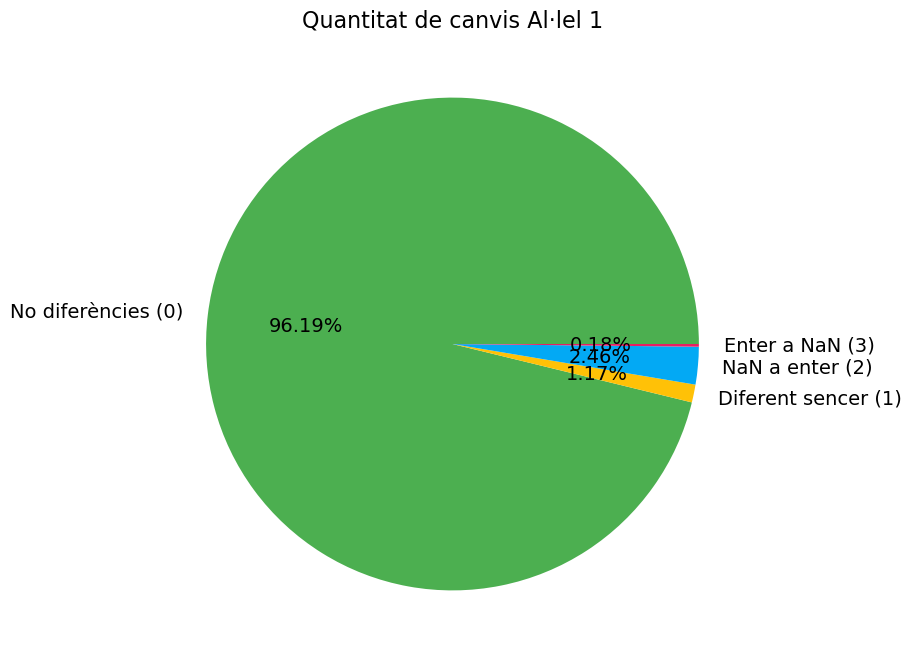

In [7]:
comparison_counts = NOAnalizadas['CorregirA1'].value_counts().sort_index()

labels = ['No diferències (0)', 'Diferent sencer (1)', 'NaN a enter (2)', 'Enter a NaN (3)']
colors = ['#4CAF50', '#FFC107', '#03A9F4', '#E91E63']

plt.figure(figsize=(8, 8))
plt.pie(
    comparison_counts, 
    labels=labels, 
    autopct='%1.2f%%', 
    colors=colors,
    textprops={'fontsize': 14}  # Aumenta el tamaño de letra de etiquetas y porcentajes
)
plt.title('Quantitat de canvis Al·lel 1', fontsize=16)  # Aumenta el tamaño del título
plt.show()

In [4]:
Analizadas = Analizadas.select_dtypes(exclude=['object', 'bool'])
NOAnalizadas = NOAnalizadas.select_dtypes(exclude=['object', 'bool'])

Analizadas = Analizadas.drop(columns=["CV", "Unnamed: 37","Allele 3", "Size 3", "Height 3","Peak Area 3",'Data Point 3','UD1'])
NOAnalizadas = NOAnalizadas.drop(columns=["CV", "Unnamed: 37", "Size 3", "Height 3","Peak Area 3",'Data Point 3','UD1'])


# Alello 1

## LR

In [25]:
NOAnalizadas=NOAnalizadas.fillna(-9999)
X=NOAnalizadas.iloc[:,:23]
y=NOAnalizadas["CorregirA1"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [174]:
reg = LogisticRegression()
reg.fit(X_train, y_train)
y_train_pred = reg.predict(X_train)
y_pred = reg.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Precisión: {:.2f}%".format(accuracy * 100))

Precisión: 97.55%


C:\Users\XIMO\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


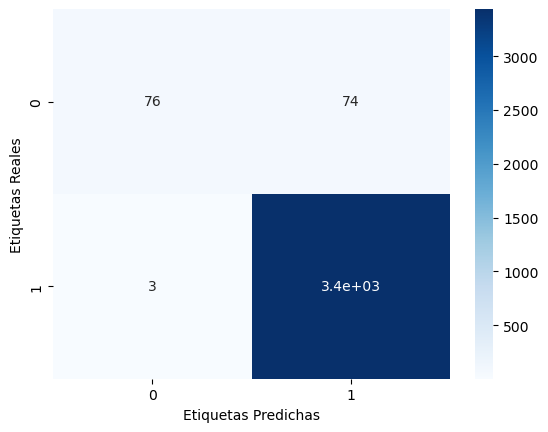

In [176]:

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, cmap='Blues')
plt.xlabel('Etiquetas Predichas')
plt.ylabel('Etiquetas Reales')
plt.show()

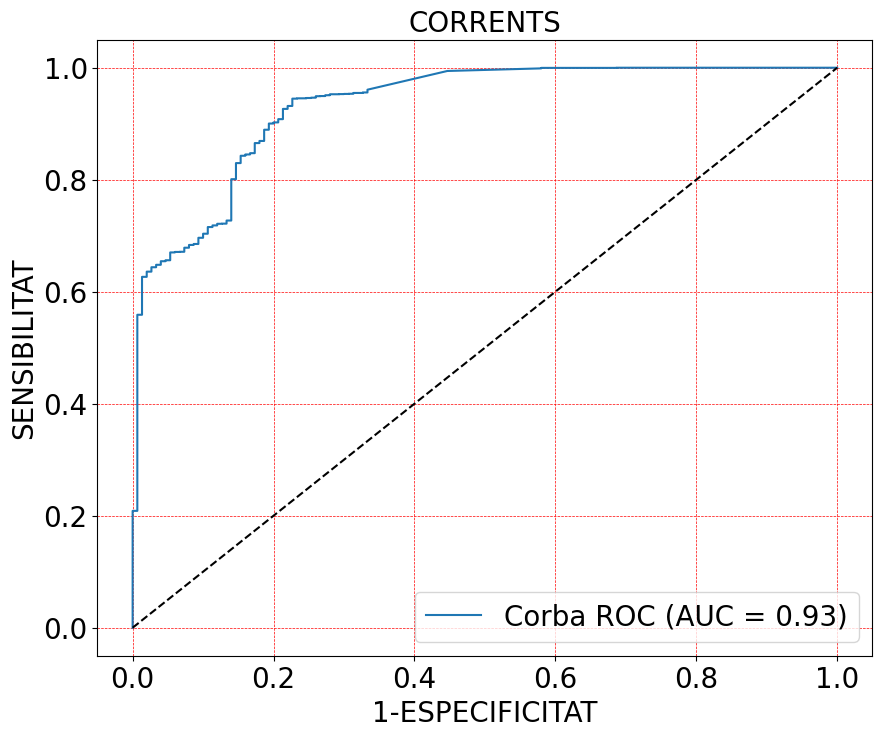

Umbral óptimo: 0.9246665753907488


In [178]:

y_probs = reg.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

youden = tpr - fpr
optimal_threshold = thresholds[np.argmax(youden)]

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label='Corba ROC (AUC = {:.2f})'.format(auc))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('1-ESPECIFICITAT',fontsize=20)
plt.ylabel('SENSIBILITAT',fontsize=20)
plt.title('CORRENTS',fontsize=20)
plt.legend(loc='lower right',fontsize=20)
plt.xticks(fontsize=20)
plt.grid(True, linestyle='--', linewidth=0.5, color='r')
plt.yticks(fontsize=20)
plt.show()

# Imprimir el umbral óptimo
print("Umbral óptimo:", optimal_threshold)

In [179]:
# Obtener las probabilidades de predicción para la clase positiva
y_probs = reg.predict_proba(X_test)[:, 1]

# Calcular la curva ROC y el área bajo la curva (AUC)
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

# Encontrar el umbral óptimo usando el punto de equilibrio (Youden's J statistic)
youden = tpr - fpr
optimal_threshold = thresholds[np.argmax(youden)]



# Clasificar las nuevas muestras utilizando el umbral óptimo
y_pred = np.where(reg.predict_proba(X_test)[:, 1] > optimal_threshold, 1, 0)

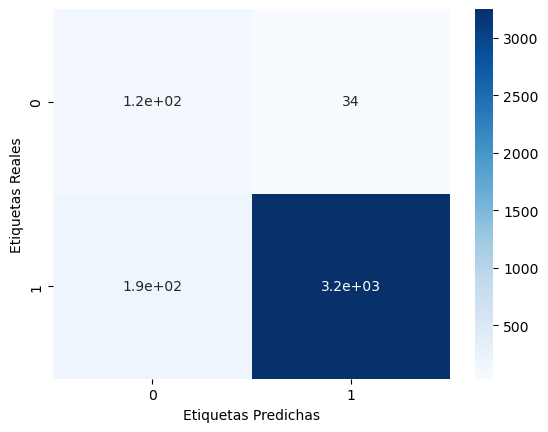

In [180]:
cm = confusion_matrix(y_test, y_pred)

# Visualizar la matriz de confusión
sns.heatmap(cm, annot=True, cmap='Blues')
plt.xlabel('Etiquetas Predichas')
plt.ylabel('Etiquetas Reales')
plt.show()

In [183]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.38      0.77      0.51       150
           1       0.99      0.94      0.97      3441

    accuracy                           0.94      3591
   macro avg       0.68      0.86      0.74      3591
weighted avg       0.96      0.94      0.95      3591



## RF

In [191]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 3, 5],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

# Crear el modelo de Random Forest
model = RandomForestClassifier()

# Realizar la búsqueda en cuadrícula
grid_search = GridSearchCV(model, param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Obtener los mejores hiperparámetros y la mejor precisión
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print("Mejores hiperparámetros:", best_params)
print("Mejor precisión:", best_score)

# Obtener el modelo con los mejores hiperparámetros y hacer predicciones en los datos de prueba
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Calcular la precisión del modelo en los datos de prueba
accuracy = accuracy_score(y_test, y_pred)
print("Precisión :", accuracy)

Mejores hiperparámetros: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Mejor precisión: 0.9795321100205836
Precisión : 0.9818991924255082


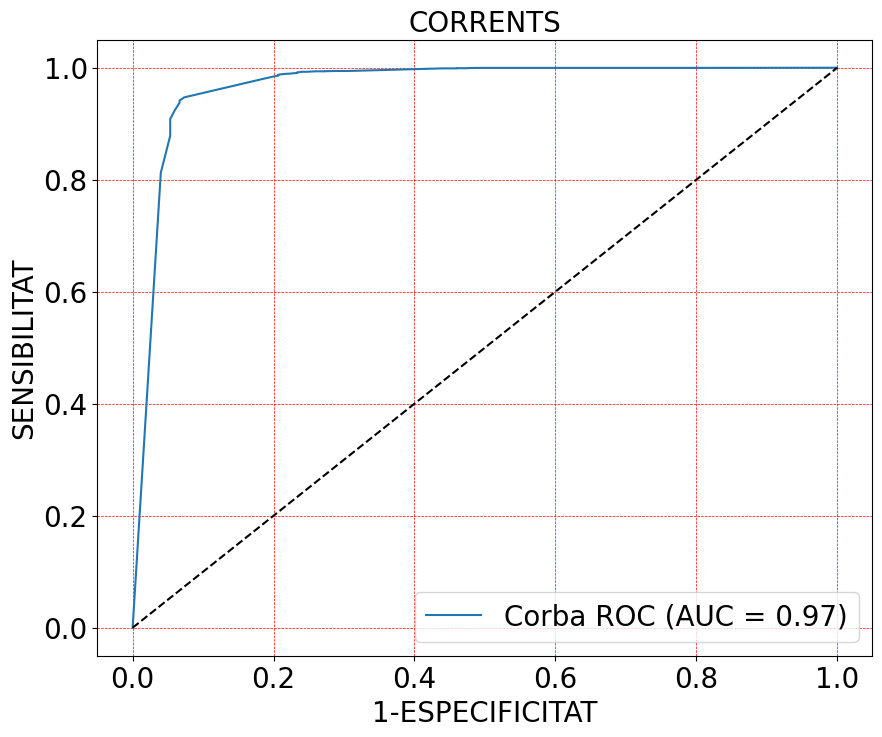

Umbral óptimo: 0.9


In [192]:
y_probs = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
pr_auc = roc_auc_score(y_test, y_probs)

youden = tpr - fpr
optimal_threshold = thresholds[np.argmax(youden)]

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label='Corba ROC (AUC = {:.2f})'.format(pr_auc))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('1-ESPECIFICITAT',fontsize=20)
plt.ylabel('SENSIBILITAT',fontsize=20)
plt.title('CORRENTS',fontsize=20)
plt.legend(loc='lower right',fontsize=20)
plt.xticks(fontsize=20)
plt.grid(True, linestyle='--', linewidth=0.5, color='r')
plt.yticks(fontsize=20)
plt.show()

# Imprimir el umbral óptimo
print("Umbral óptimo:", optimal_threshold)

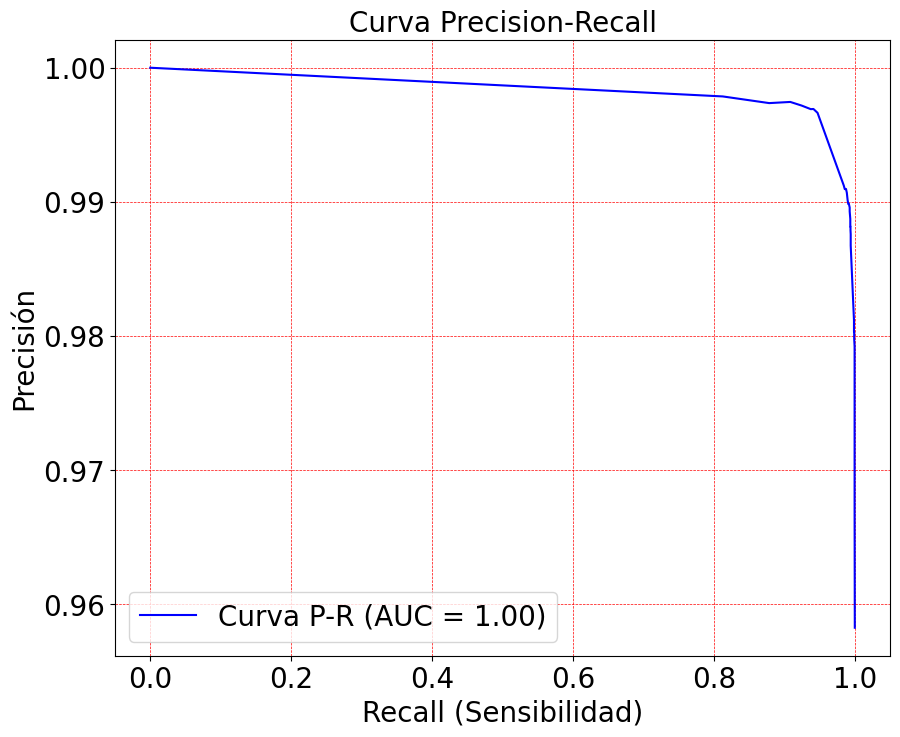

In [193]:


# Obtener las probabilidades de la clase positiva
y_probs = best_model.predict_proba(X_test)[:, 1]

# Calcular precisión, recall y umbrales
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_probs)

# Calcular el área bajo la curva Precision-Recall
pr_auc = auc(recall, precision)

# Visualización de la curva Precision-Recall
plt.figure(figsize=(10, 8))
plt.plot(recall, precision, label='Curva P-R (AUC = {:.2f})'.format(pr_auc), color='b')
plt.xlabel('Recall (Sensibilidad)', fontsize=20)
plt.ylabel('Precisión', fontsize=20)
plt.title('Curva Precision-Recall', fontsize=20)
plt.legend(loc='lower left', fontsize=20)
plt.grid(True, linestyle='--', linewidth=0.5, color='r')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

In [197]:
cm = confusion_matrix(y_test, y_pred)
cm = cm.astype(int)
# Visualizar la matriz de confusión
np.set_printoptions(suppress=True)
cm_df = pd.DataFrame(cm, index=['Clase 0', 'Clase 1'], columns=['Predicción 0', 'Predicción 1'])

print(cm_df)

         Predicción 0  Predicción 1
Clase 0           105            45
Clase 1            20          3421


In [201]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.70      0.76       150
           1       0.99      0.99      0.99      3441

    accuracy                           0.98      3591
   macro avg       0.91      0.85      0.88      3591
weighted avg       0.98      0.98      0.98      3591



# Alelo 1 con reducción

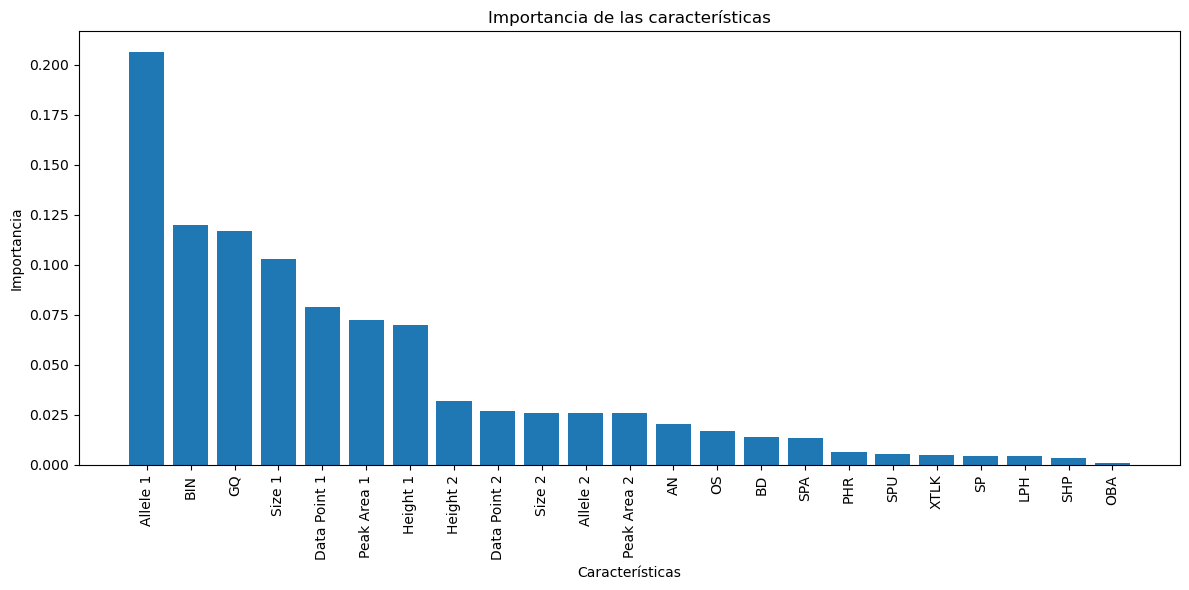

In [25]:
NOAnalizadas=NOAnalizadas.fillna(-9999)
X=NOAnalizadas.iloc[:,:23]
y=NOAnalizadas["CorregirA1"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Obtén las importancias de características
importances = rf.feature_importances_
feature_names = X.columns

# Ordena las importancias de características
indices = np.argsort(importances)[::-1]

# Visualiza las importancias de las características
plt.figure(figsize=(12, 6))
plt.title('Importancia de las características')
plt.bar(range(X.shape[1]), importances[indices], align='center')
plt.xticks(range(X.shape[1]), feature_names[indices], rotation=90)
plt.xlabel('Características')
plt.ylabel('Importancia')
plt.tight_layout()
plt.show()

# Selecciona las mejores k características
k = 7
best_indices = indices[:k]
best_feature_names = feature_names[best_indices]

# Convierte X_train y X_test a matrices NumPy
X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()

# Selecciona las mejores características
X_train_selected = X_train_np[:, best_indices]
X_test_selected = X_test_np[:, best_indices]

In [11]:
reg = LogisticRegression()
reg.fit(X_train_selected, y_train)
y_train_pred = reg.predict(X_train_selected)
y_pred = reg.predict(X_test_selected)
accuracy = accuracy_score(y_test, y_pred)
print("Precisión: {:.2f}%".format(accuracy * 100))

Precisión: 97.47%


In [34]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 3, 5],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

# Crear el modelo de Random Forest
model = RandomForestClassifier(class_weight='balanced', random_state=42)

# Realizar la búsqueda en cuadrícula
grid_search = GridSearchCV(model, param_grid, cv=5)
grid_search.fit(X_train_selected, y_train)

# Obtener los mejores hiperparámetros y la mejor precisión
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print("Mejores hiperparámetros:", best_params)
print("Mejor precisión:", best_score)

# Obtener el modelo con los mejores hiperparámetros y hacer predicciones en los datos de prueba
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_selected)

# Calcular la precisión del modelo en los datos de prueba
accuracy = accuracy_score(y_test, y_pred)
print("Precisión :", accuracy)


Mejores hiperparámetros: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Mejor precisión: 0.9466718036623757
Precisión : 0.9554441659704818


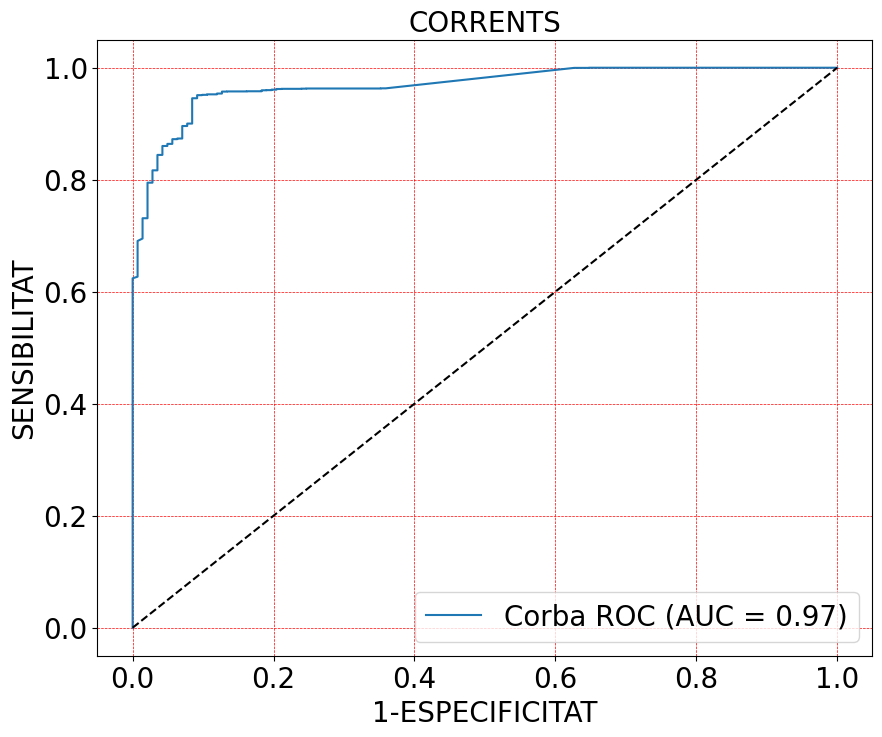

Umbral óptimo: 0.8103326024621852


In [35]:

y_probs = best_model.predict_proba(X_test_selected)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
pr_auc = roc_auc_score(y_test, y_probs)

youden = tpr - fpr
optimal_threshold = thresholds[np.argmax(youden)]

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label='Corba ROC (AUC = {:.2f})'.format(pr_auc))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('1-ESPECIFICITAT',fontsize=20)
plt.ylabel('SENSIBILITAT',fontsize=20)
plt.title('CORRENTS',fontsize=20)
plt.legend(loc='lower right',fontsize=20)
plt.xticks(fontsize=20)
plt.grid(True, linestyle='--', linewidth=0.5, color='r')
plt.yticks(fontsize=20)
plt.show()

# Imprimir el umbral óptimo
print("Umbral óptimo:", optimal_threshold)

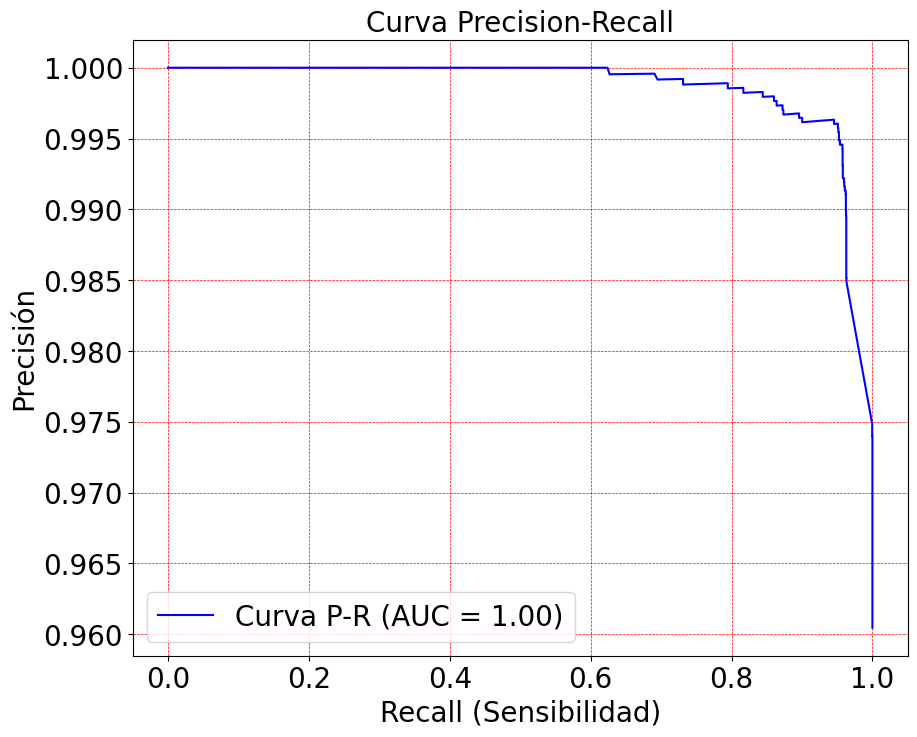

In [36]:

y_probs = best_model.predict_proba(X_test_selected)[:, 1]

# Calcular precisión, recall y umbrales
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_probs)

# Calcular el área bajo la curva Precision-Recall
pr_auc = auc(recall, precision)

# Visualización de la curva Precision-Recall
plt.figure(figsize=(10, 8))
plt.plot(recall, precision, label='Curva P-R (AUC = {:.2f})'.format(pr_auc), color='b')
plt.xlabel('Recall (Sensibilidad)', fontsize=20)
plt.ylabel('Precisión', fontsize=20)
plt.title('Curva Precision-Recall', fontsize=20)
plt.legend(loc='lower left', fontsize=20)
plt.grid(True, linestyle='--', linewidth=0.5, color='r')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

In [40]:
cm = confusion_matrix(y_test, y_pred)
cm = cm.astype(int)
# Visualizar la matriz de confusión
np.set_printoptions(suppress=True)
cm_df = pd.DataFrame(cm, index=['Clase 0', 'Clase 1'], columns=['Predicción 0', 'Predicción 1'])

print(cm_df)

         Predicción 0  Predicción 1
Clase 0           113            29
Clase 1           131          3318


In [41]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.46      0.80      0.59       142
           1       0.99      0.96      0.98      3449

    accuracy                           0.96      3591
   macro avg       0.73      0.88      0.78      3591
weighted avg       0.97      0.96      0.96      3591



# Alelo 2

## LR

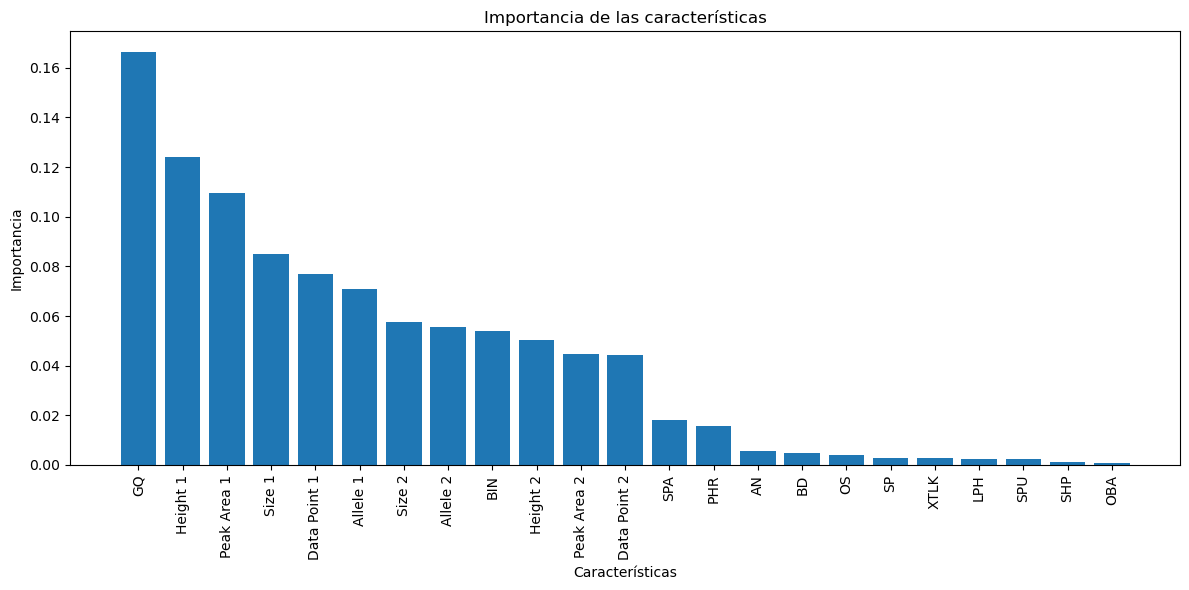

In [38]:
NOAnalizadas=NOAnalizadas.fillna(-9999)
X=NOAnalizadas.iloc[:,:23]
y=NOAnalizadas["CorregirA2"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Obtén las importancias de características
importances = rf.feature_importances_
feature_names = X.columns

# Ordena las importancias de características
indices = np.argsort(importances)[::-1]

# Visualiza las importancias de las características
plt.figure(figsize=(12, 6))
plt.title('Importancia de las características')
plt.bar(range(X.shape[1]), importances[indices], align='center')
plt.xticks(range(X.shape[1]), feature_names[indices], rotation=90)
plt.xlabel('Características')
plt.ylabel('Importancia')
plt.tight_layout()
plt.show()

# Selecciona las mejores k características
k = 12
best_indices = indices[:k]
best_feature_names = feature_names[best_indices]

# Convierte X_train y X_test a matrices NumPy
X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()

# Selecciona las mejores características
X_train_selected = X_train_np[:, best_indices]
X_test_selected = X_test_np[:, best_indices]

In [44]:
reg = LogisticRegression(class_weight="balanced")
reg.fit(X_train_selected, y_train)
y_train_pred = reg.predict(X_train_selected)
y_pred = reg.predict(X_test_selected)
accuracy = accuracy_score(y_test, y_pred)
print("Precisión: {:.2f}%".format(accuracy * 100))

Precisión: 84.49%


C:\Users\XIMO\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


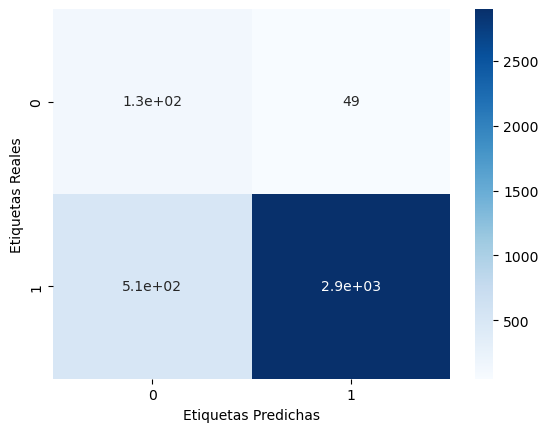

In [45]:

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, cmap='Blues')
plt.xlabel('Etiquetas Predichas')
plt.ylabel('Etiquetas Reales')
plt.show()

In [46]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.21      0.73      0.32       182
           1       0.98      0.85      0.91      3409

    accuracy                           0.84      3591
   macro avg       0.60      0.79      0.62      3591
weighted avg       0.94      0.84      0.88      3591



## RF

In [47]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 3, 5],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

# Crear el modelo de Random Forest
model = RandomForestClassifier(class_weight='balanced', random_state=42)

# Realizar la búsqueda en cuadrícula
grid_search = GridSearchCV(model, param_grid, cv=5)
grid_search.fit(X_train_selected, y_train)

# Obtener los mejores hiperparámetros y la mejor precisión
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print("Mejores hiperparámetros:", best_params)
print("Mejor precisión:", best_score)

# Obtener el modelo con los mejores hiperparámetros y hacer predicciones en los datos de prueba
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_selected)

# Calcular la precisión del modelo en los datos de prueba
accuracy = accuracy_score(y_test, y_pred)
print("Precisión :", accuracy)


Mejores hiperparámetros: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Mejor precisión: 0.9418683894912483
Precisión : 0.9426343636869953


In [48]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.46      0.77      0.58       182
           1       0.99      0.95      0.97      3409

    accuracy                           0.94      3591
   macro avg       0.72      0.86      0.77      3591
weighted avg       0.96      0.94      0.95      3591



In [49]:
cm = confusion_matrix(y_test, y_pred)
cm = cm.astype(int)
# Visualizar la matriz de confusión
np.set_printoptions(suppress=True)
cm_df = pd.DataFrame(cm, index=['Clase 0', 'Clase 1'], columns=['Predicción 0', 'Predicción 1'])

print(cm_df)

         Predicción 0  Predicción 1
Clase 0           140            42
Clase 1           164          3245


In [50]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

# Escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Ajustar y transformar sobre X_train
X_test_scaled = scaler.transform(X_test)       # Sólo transformar X_test

# Aplicar PCA, seleccionando componentes que expliquen el 95% de la varianza
pca = PCA(n_components=0.95)  # 0.95 para retener el 95% de la varianza
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Resultados
print(f"Número de componentes seleccionadas: {pca.n_components_}")
print(f"Varianza explicada por cada componente: {pca.explained_variance_ratio_}")
print(f"Varianza acumulada: {np.cumsum(pca.explained_variance_ratio_)}")


Número de componentes seleccionadas: 6
Varianza explicada por cada componente: [0.49180176 0.22267054 0.10148304 0.06988512 0.04535813 0.02759   ]
Varianza acumulada: [0.49180176 0.7144723  0.81595534 0.88584046 0.93119859 0.95878859]


In [56]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_pca, y_train)

# Predecir en los datos de prueba
y_pred = rf.predict(X_test_pca)

# Evaluar el rendimiento del modelo
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

# Matriz de confusión
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9654692286271234

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.77      0.45      0.57       182
           1       0.97      0.99      0.98      3409

    accuracy                           0.97      3591
   macro avg       0.87      0.72      0.78      3591
weighted avg       0.96      0.97      0.96      3591


Matriz de confusión:
[[  82  100]
 [  24 3385]]


In [57]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 3, 5],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

# Crear el modelo de Random Forest
model = RandomForestClassifier(random_state=42)

# Realizar la búsqueda en cuadrícula
grid_search = GridSearchCV(model, param_grid, cv=5)
grid_search.fit(X_train_pca, y_train)

# Obtener los mejores hiperparámetros y la mejor precisión
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print("Mejores hiperparámetros:", best_params)
print("Mejor precisión:", best_score)

# Obtener el modelo con los mejores hiperparámetros y hacer predicciones en los datos de prueba
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_pca)

# Calcular la precisión del modelo en los datos de prueba
accuracy = accuracy_score(y_test, y_pred)
print("Precisión :", accuracy)


Mejores hiperparámetros: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
Mejor precisión: 0.9714562970776812
Precisión : 0.9663046505151768


In [58]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.46      0.58       182
           1       0.97      0.99      0.98      3409

    accuracy                           0.97      3591
   macro avg       0.88      0.73      0.78      3591
weighted avg       0.96      0.97      0.96      3591



In [60]:

# Matriz de confusión
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))


Matriz de confusión:
[[  84   98]
 [  23 3386]]


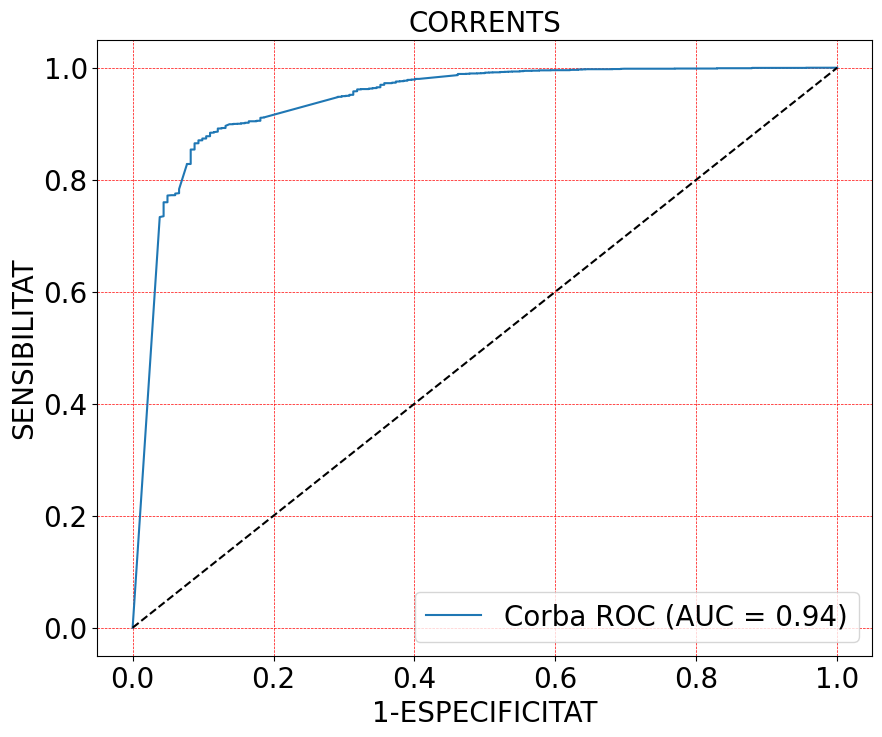

Umbral óptimo: 0.96


In [61]:

y_probs = best_model.predict_proba(X_test_pca)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
pr_auc = roc_auc_score(y_test, y_probs)

youden = tpr - fpr
optimal_threshold = thresholds[np.argmax(youden)]

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label='Corba ROC (AUC = {:.2f})'.format(pr_auc))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('1-ESPECIFICITAT',fontsize=20)
plt.ylabel('SENSIBILITAT',fontsize=20)
plt.title('CORRENTS',fontsize=20)
plt.legend(loc='lower right',fontsize=20)
plt.xticks(fontsize=20)
plt.grid(True, linestyle='--', linewidth=0.5, color='r')
plt.yticks(fontsize=20)
plt.show()

# Imprimir el umbral óptimo
print("Umbral óptimo:", optimal_threshold)

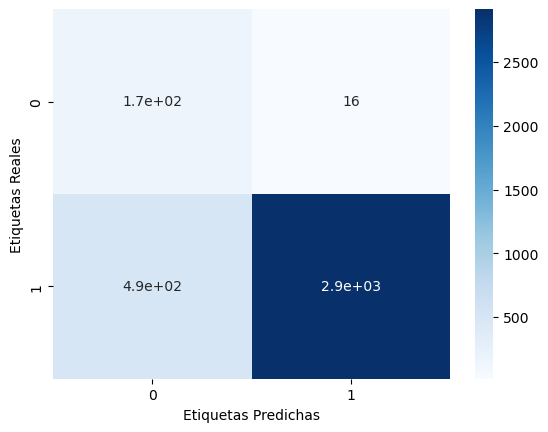

In [64]:
y_pred = np.where(best_model.predict_proba(X_test_pca)[:, 1] > optimal_threshold, 1, 0)
# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Visualizar la matriz de confusión
sns.heatmap(cm, annot=True, cmap='Blues')
plt.xlabel('Etiquetas Predichas')
plt.ylabel('Etiquetas Reales')
plt.show()

# Detector con reducción


In [6]:
# rows_with_0 = NOAnalizadas[NOAnalizadas['CorregirA1'] == 0].copy()

# column_mean = rows_with_0["Allele 1"].mean()

# # Calcular el impacto de cada fila en la varianza
# rows_with_0['variance_contribution'] = (rows_with_0["Allele 1"] - column_mean) ** 2

# # Ordenar las filas por contribución a la varianza (de mayor a menor)
# rows_with_0 = rows_with_0.sort_values(by='variance_contribution', ascending=False)

# # Seleccionar las primeras 4000 filas
# sampled_rows_with_0 = rows_with_0.head(200)

# sampled_rows_with_0 = sampled_rows_with_0.drop(columns=['variance_contribution'])
rows_with_0 = NOAnalizadas[NOAnalizadas['CorregirA1'] == 0].copy()
# Filtrar las filas con valores 2 o 1
rows_with_2_and_1 = NOAnalizadas[NOAnalizadas['CorregirA1']==1]
rows_with_0 = rows_with_0.sample(n=500, random_state=42)
# Combinar las filas seleccionadas
final_selection = pd.concat([rows_with_0, rows_with_2_and_1])

# Crear el DataFrame final y asignar la columna 'y'
X = final_selection.copy()
# X['y'] = np.where(X['CorregirA1'] == 0, 0, 1)


In [7]:
X["CorregirA1"].value_counts()

CorregirA1
0    500
1    187
Name: count, dtype: int64

In [8]:
X=final_selection.fillna(-9999)
y=X["CorregirA1"]
X=X.iloc[:,:23]
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

In [79]:
rf = RandomForestClassifier(
    random_state=42,
    max_depth=10,            # Limita la profundidad de los árboles
    min_samples_split=10,    # Número mínimo de muestras para dividir un nodo
    min_samples_leaf=5, class_weight='balanced'       # Mínimo de muestras en las hojas
)
rf.fit(X_train, y_train)

# Predecir en los datos de prueba
y_pred = rf.predict(X_test)

# Evaluar el rendimiento del modelo
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

# Matriz de confusión
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8876404494382022

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.96      0.90      0.93       150
           1       0.61      0.82      0.70        28

    accuracy                           0.89       178
   macro avg       0.78      0.86      0.81       178
weighted avg       0.91      0.89      0.89       178


Matriz de confusión:
[[135  15]
 [  5  23]]


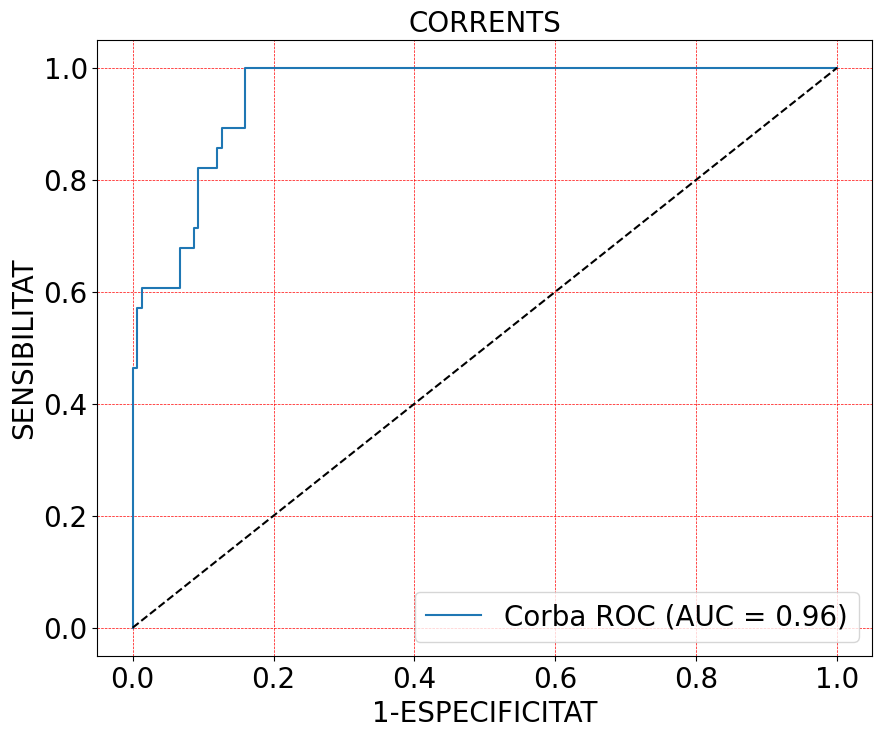

Umbral óptimo: 0.3391141410246666


In [81]:

y_probs = rf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
pr_auc = roc_auc_score(y_test, y_probs)

youden = tpr - fpr
optimal_threshold = thresholds[np.argmax(youden)]

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label='Corba ROC (AUC = {:.2f})'.format(pr_auc))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('1-ESPECIFICITAT',fontsize=20)
plt.ylabel('SENSIBILITAT',fontsize=20)
plt.title('CORRENTS',fontsize=20)
plt.legend(loc='lower right',fontsize=20)
plt.xticks(fontsize=20)
plt.grid(True, linestyle='--', linewidth=0.5, color='r')
plt.yticks(fontsize=20)
plt.show()

# Imprimir el umbral óptimo
print("Umbral óptimo:", optimal_threshold)

In [82]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Ajustar y transformar sobre X_train
X_test_scaled = scaler.transform(X_test)       # Sólo transformar X_test

# Aplicar PCA, seleccionando componentes que expliquen el 95% de la varianza
pca = PCA(n_components=0.95)  # 0.95 para retener el 95% de la varianza
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Resultados
print(f"Número de componentes seleccionadas: {pca.n_components_}")
print(f"Varianza explicada por cada componente: {pca.explained_variance_ratio_}")
print(f"Varianza acumulada: {np.cumsum(pca.explained_variance_ratio_)}")


Número de componentes seleccionadas: 6
Varianza explicada por cada componente: [0.41146476 0.23396746 0.13603615 0.09054046 0.06822868 0.0348952 ]
Varianza acumulada: [0.41146476 0.64543223 0.78146838 0.87200883 0.94023751 0.97513271]


In [83]:
rf = RandomForestClassifier(
    random_state=42, 
    class_weight="balanced", 
    min_samples_split=10, 
    min_samples_leaf=5, 
    max_depth=10
)
rf.fit(X_train_pca, y_train)
y_pred = rf.predict(X_test_pca)

# Evaluación
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.8876404494382022

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93       150
           1       0.62      0.75      0.68        28

    accuracy                           0.89       178
   macro avg       0.78      0.83      0.80       178
weighted avg       0.90      0.89      0.89       178


Matriz de confusión:
[[137  13]
 [  7  21]]


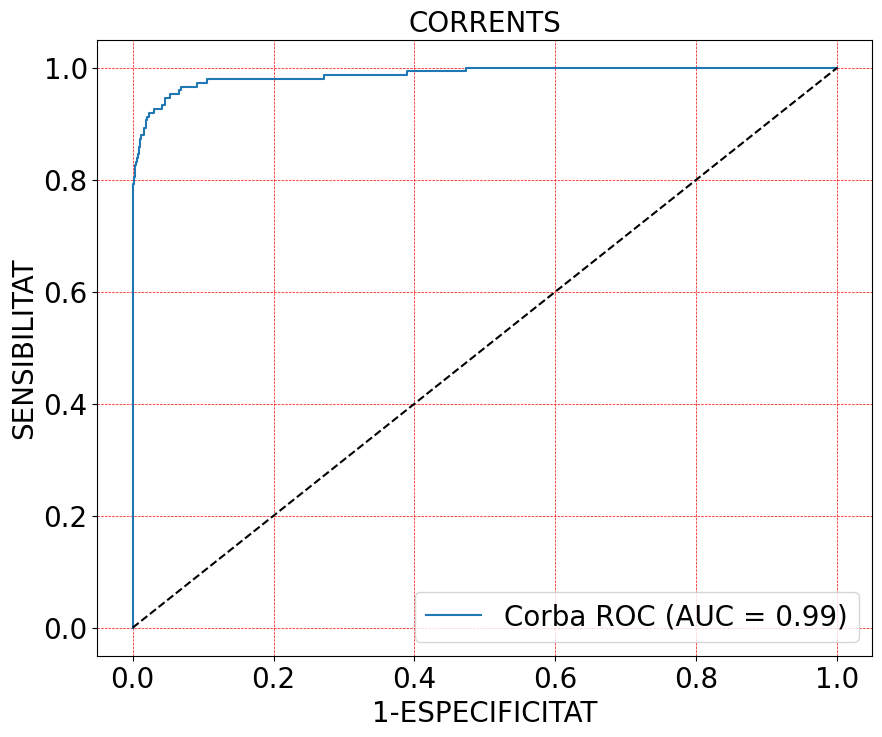

Umbral óptimo: 0.22640549792295558


In [96]:

y_probs = rf.predict_proba(X_test_pca)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
pr_auc = roc_auc_score(y_test, y_probs)

youden = tpr - fpr
optimal_threshold = thresholds[np.argmax(youden)]

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label='Corba ROC (AUC = {:.2f})'.format(pr_auc))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('1-ESPECIFICITAT',fontsize=20)
plt.ylabel('SENSIBILITAT',fontsize=20)
plt.title('CORRENTS',fontsize=20)
plt.legend(loc='lower right',fontsize=20)
plt.xticks(fontsize=20)
plt.grid(True, linestyle='--', linewidth=0.5, color='r')
plt.yticks(fontsize=20)
plt.show()

# Imprimir el umbral óptimo
print("Umbral óptimo:", optimal_threshold)

In [97]:
y_pred_custom = (y_probs >= optimal_threshold).astype(int)

# Evaluar el rendimiento
print("Accuracy:", accuracy_score(y_test, y_pred_custom))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_custom))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_custom))

Accuracy: 0.9484978540772532

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       783
           1       0.78      0.95      0.86       149

    accuracy                           0.95       932
   macro avg       0.88      0.95      0.91       932
weighted avg       0.96      0.95      0.95       932


Matriz de confusión:
[[742  41]
 [  7 142]]


In [100]:
scale_pos_weight=700/187
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# Definir el modelo base
xgb = XGBClassifier(
    objective="binary:logistic",
    scale_pos_weight=scale_pos_weight,  # Para clases desbalanceadas
    random_state=42
)

# Definir la cuadrícula de parámetros
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],           # Diferentes tasas de aprendizaje
    'max_depth': [3, 4, 5, 6],                          # Profundidad de los árboles
    'n_estimators': [100, 200, 500],                    # Número de árboles (estimadores)
    'colsample_bytree': [0.5, 0.7, 1],                  # Fracción de características por árbol
    'subsample': [0.6, 0.8, 1],                         # Fracción de datos para cada árbol
    'gamma': [0, 1, 5],                                 # Regularización de complejidad del árbol
    'reg_alpha': [0, 1, 5],                             # L1 regularization (penalización L1)
    'reg_lambda': [1, 10, 50]                           # L2 regularization (penalización L2)
}

# Configurar la búsqueda en cuadrícula
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="f1",             # Optimizar F1 score
    cv=3,                     # Validación cruzada con 3 particiones
    verbose=1,
    n_jobs=-1                 # Usar todos los núcleos disponibles para acelerar la búsqueda
)

# Ajustar la búsqueda en cuadrícula al conjunto de datos de entrenamiento
grid_search.fit(X_train, y_train)

# Mejor modelo y parámetros encontrados
best_model = grid_search.best_estimator_
best_params = grid_search.best_params_

print("Mejores parámetros encontrados:", best_params)

# Entrenar el mejor modelo
best_model.fit(X_train, y_train)

# Predicciones con el mejor modelo
preds = best_model.predict(X_test)

# Evaluación del modelo
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("\nAccuracy:", accuracy_score(y_test, preds))
print("\nReporte de clasificación:")
print(classification_report(y_test, preds))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, preds))


Fitting 3 folds for each of 11664 candidates, totalling 34992 fits
Mejores parámetros encontrados: {'colsample_bytree': 0.5, 'gamma': 0, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100, 'reg_alpha': 1, 'reg_lambda': 1, 'subsample': 0.8}

Accuracy: 0.9325842696629213

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       150
           1       0.81      0.75      0.78        28

    accuracy                           0.93       178
   macro avg       0.88      0.86      0.87       178
weighted avg       0.93      0.93      0.93       178


Matriz de confusión:
[[145   5]
 [  7  21]]


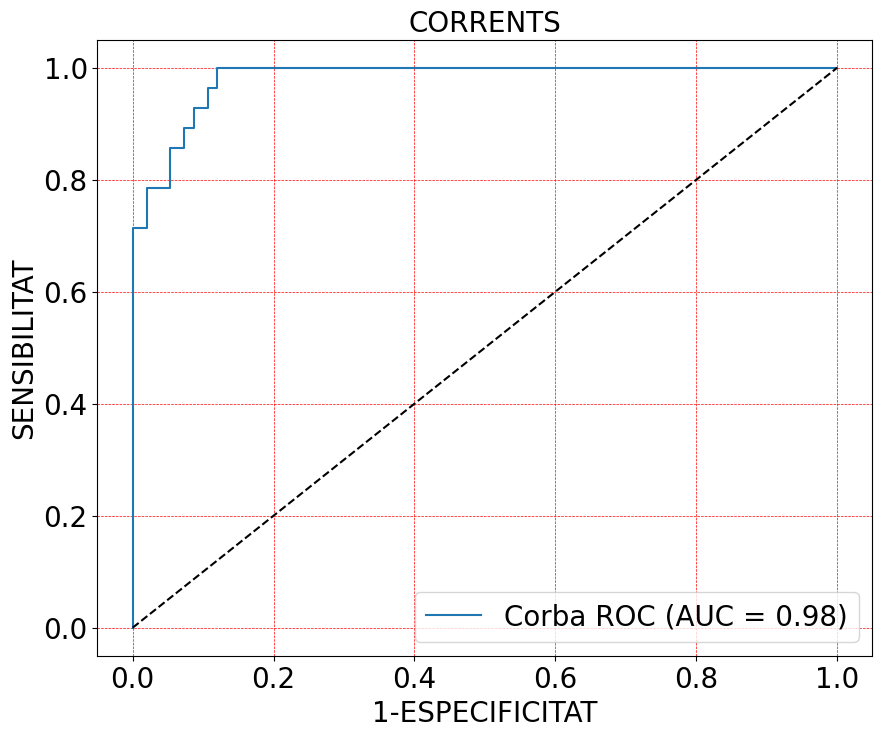

Umbral óptimo: 0.033068724


In [101]:

y_probs = bst.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
pr_auc = roc_auc_score(y_test, y_probs)

youden = tpr - fpr
optimal_threshold = thresholds[np.argmax(youden)]

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label='Corba ROC (AUC = {:.2f})'.format(pr_auc))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('1-ESPECIFICITAT',fontsize=20)
plt.ylabel('SENSIBILITAT',fontsize=20)
plt.title('CORRENTS',fontsize=20)
plt.legend(loc='lower right',fontsize=20)
plt.xticks(fontsize=20)
plt.grid(True, linestyle='--', linewidth=0.5, color='r')
plt.yticks(fontsize=20)
plt.show()

# Imprimir el umbral óptimo
print("Umbral óptimo:", optimal_threshold)

In [94]:
from sklearn.feature_selection import SelectFromModel
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Entrenar un modelo inicial para calcular importancias
base_model = XGBClassifier(
    objective="binary:logistic",
    colsample_bytree=0.5,   # Usar más características por árbol (de 0.1 a 0.5)
    gamma=0,                # Reducir regularización (de 2 a 0)
    learning_rate=0.01,     # Aumentar la tasa de aprendizaje (de 0.005 a 0.01)
    max_depth=4,            # Aumentar la profundidad de los árboles (de 2 a 4)
    n_estimators=500,       # Mantener número de árboles para selección inicial
    subsample=0.8,          # Usar más datos en cada árbol (de 0.2 a 0.8)
    scale_pos_weight=scale_pos_weight,  # Mantener el balance
    random_state=42,
    alpha=0,                # Eliminar regularización L1
    reg_alpha=5,            # Reducir regularización adicional L1 (de 20 a 5)
    reg_lambda=10           # Reducir regularización L2 (de 50 a 10)
)

base_model.fit(X_train, y_train)

# Selección de características basada en importancia
selector = SelectFromModel(base_model, threshold="mean", prefit=True)
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

# Entrenar el modelo con las características seleccionadas
bst = XGBClassifier(
    objective="binary:logistic",
    colsample_bytree=0.5,   # Usar más características por árbol
    gamma=0,                # Reducir regularización
    learning_rate=0.01,     # Aumentar la tasa de aprendizaje
    max_depth=4,            # Aumentar la profundidad
    n_estimators=800,       # Reducir el número de árboles para evitar sobreajuste
    subsample=0.8,          # Usar más datos por árbol
    scale_pos_weight=scale_pos_weight,  # Mantener balance
    random_state=42,
    alpha=0,                # Eliminar regularización L1
    reg_alpha=5,            # Reducir regularización adicional L1
    reg_lambda=10           # Reducir regularización L2
)

bst.fit(X_train_selected, y_train)

# Hacer predicciones
preds = bst.predict(X_test_selected)

# Métricas
print("Accuracy:", accuracy_score(y_test, preds))
print("\nReporte de clasificación:")
print(classification_report(y_test, preds))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, preds))


C:\Users\XIMO\anaconda3\Lib\site-packages\sklearn\base.py:457: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\XIMO\anaconda3\Lib\site-packages\sklearn\base.py:457: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Accuracy: 0.8595505617977528

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.97      0.86      0.91       150
           1       0.53      0.86      0.66        28

    accuracy                           0.86       178
   macro avg       0.75      0.86      0.78       178
weighted avg       0.90      0.86      0.87       178


Matriz de confusión:
[[129  21]
 [  4  24]]


In [30]:
clf = ExtraTreesClassifier(max_depth=20, max_features=None, min_samples_leaf=1,
                           min_samples_split=2,n_estimators=100,random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)
# Evaluación en el conjunto de prueba
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.9325842696629213

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96       150
           1       0.79      0.79      0.79        28

    accuracy                           0.93       178
   macro avg       0.87      0.87      0.87       178
weighted avg       0.93      0.93      0.93       178


Matriz de confusión:
[[144   6]
 [  6  22]]


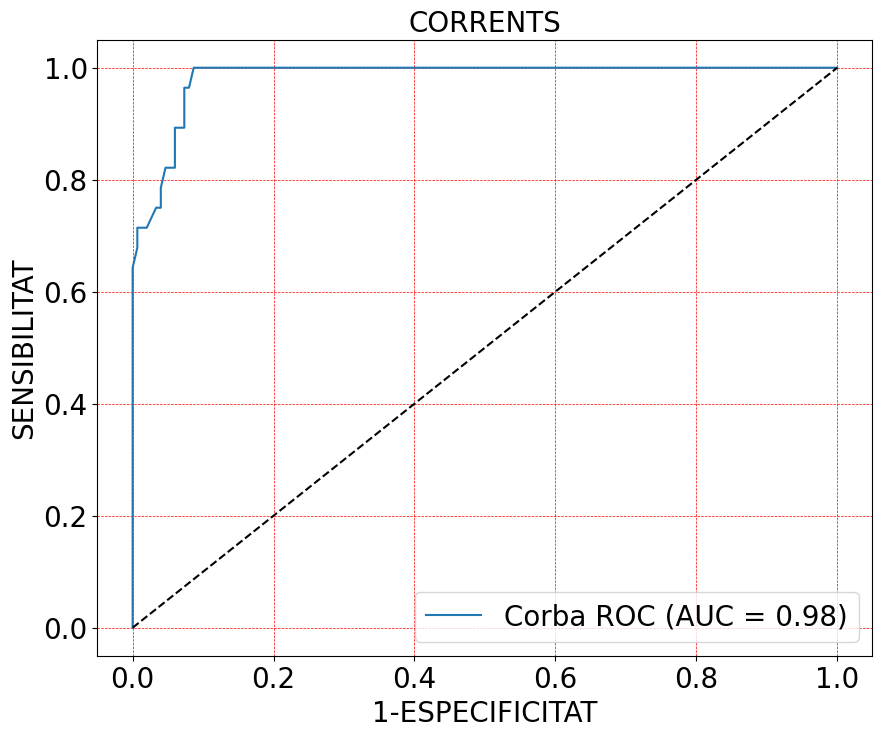

Umbral óptimo: 0.2


In [32]:

y_probs = clf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
pr_auc = roc_auc_score(y_test, y_probs)

youden = tpr - fpr
optimal_threshold = thresholds[np.argmax(youden)]

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label='Corba ROC (AUC = {:.2f})'.format(pr_auc))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('1-ESPECIFICITAT',fontsize=20)
plt.ylabel('SENSIBILITAT',fontsize=20)
plt.title('CORRENTS',fontsize=20)
plt.legend(loc='lower right',fontsize=20)
plt.xticks(fontsize=20)
plt.grid(True, linestyle='--', linewidth=0.5, color='r')
plt.yticks(fontsize=20)
plt.show()

# Imprimir el umbral óptimo
print("Umbral óptimo:", optimal_threshold)

In [41]:
import lightgbm as lgb
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

lgbm = lgb.LGBMClassifier(
    boosting_type='gbdt',
    objective='binary',
    scale_pos_weight=scale_pos_weight,
    min_gain_to_split=0.01,
    min_data_in_leaf=10,
    max_depth=-1,
    random_state=42
)

# Espacio de búsqueda de hiperparámetros
param_grid = {
    'num_leaves': [15, 31, 50],  # Tamaño de las hojas (menores tamaños pueden evitar sobreajuste)
    'learning_rate': [0.005, 0.01, 0.05],  # Tasas de aprendizaje más pequeñas para mayor precisión
    'n_estimators': [300, 500, 700],  # Más árboles para un mejor ajuste
    'colsample_bytree': [0.6, 0.8, 1.0],  # Fracción de características usadas por árbol
    'subsample': [0.6, 0.8, 1.0],  # Fracción de muestras usadas por árbol
    'reg_alpha': [0, 0.1, 0.5],  # Regularización L1
    'reg_lambda': [0, 0.1, 0.5]  # Regularización L2
}

# GridSearchCV para encontrar los mejores hiperparámetros
grid_search = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    cv=5,
    scoring='f1',  # Métrica que da peso al equilibrio entre precision y recall
    n_jobs=-1,
    verbose=2
)
grid_search.fit(X_train, y_train)

# Mejor modelo encontrado
best_lgbm = grid_search.best_estimator_

# Evaluación del modelo en el conjunto de prueba
y_pred = best_lgbm.predict(X_test)
y_pred_proba = best_lgbm.predict_proba(X_test)[:, 1]

# Imprimir resultados
print("Mejores hiperparámetros:", grid_search.best_params_)
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nROC AUC:", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Fitting 5 folds for each of 2187 candidates, totalling 10935 fits
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_gain_to_split is set=0.01, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.01
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_gain_to_split is set=0.01, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.01
[LightGBM] [Info] Number of positive: 159, number of negative: 550
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000442 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1677
[LightGBM] [Info] Number of data points in the train set: 709, number of used features: 22
[Lig

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

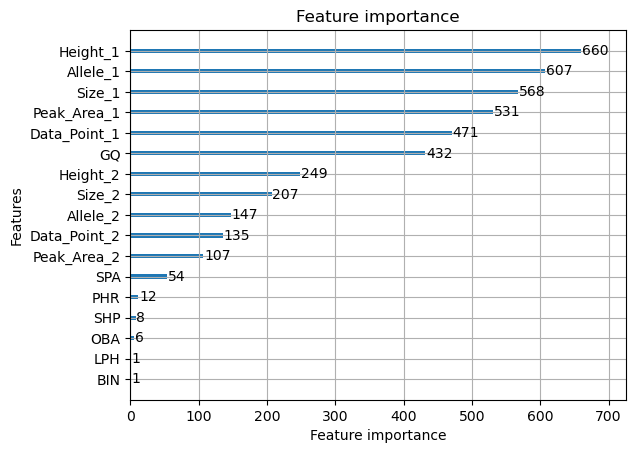

In [46]:
# {'colsample_bytree': 0.6, 'learning_rate': 0.05, 'n_estimators': 300, 'num_leaves': 15, 'reg_alpha': 0.1, 'reg_lambda': 0.5, 'subsample': 0.6}
lgb.plot_importance(best_lgbm, max_num_features=20)


In [49]:
from catboost import CatBoostClassifier
# Calcular los pesos de las clases
class_weights = [len(y_train[y_train == 0]) / len(y_train), 
                 len(y_train[y_train == 1]) / len(y_train)]

# Inicialización del modelo CatBoost
catboost_model = CatBoostClassifier(
    iterations=500,                 # Número de iteraciones (árboles)
    learning_rate=0.1,              # Tasa de aprendizaje inicial
    depth=6,                        # Profundidad de los árboles
    class_weights=class_weights,    # Ponderación de clases
    eval_metric='F1',               # Métrica a optimizar (puedes cambiar a 'AUC')
    random_seed=42,
    verbose=50                      # Frecuencia de salida de progreso
)

# Entrenar el modelo
catboost_model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=50)

# Predicciones
y_pred = catboost_model.predict(X_test)
y_pred_proba = catboost_model.predict_proba(X_test)[:, 1]

# Evaluación del modelo
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nROC AUC:", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

0:	learn: 0.0000000	test: 0.0000000	best: 0.0000000 (0)	total: 110ms	remaining: 55.1s
50:	learn: 0.8222222	test: 0.6666667	best: 0.6666667 (44)	total: 315ms	remaining: 2.77s
100:	learn: 0.9034483	test: 0.7272727	best: 0.7272727 (91)	total: 494ms	remaining: 1.95s
150:	learn: 0.9435216	test: 0.7530849	best: 0.7826087 (123)	total: 680ms	remaining: 1.57s
200:	learn: 0.9675325	test: 0.8006234	best: 0.8333333 (152)	total: 870ms	remaining: 1.29s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8333333333
bestIteration = 152

Shrink model to first 153 iterations.

Accuracy: 0.9550561797752809

ROC AUC: 0.9859523809523809

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97       150
           1       1.00      0.71      0.83        28

    accuracy                           0.96       178
   macro avg       0.97      0.86      0.90       178
weighted avg       0.96      0.96      0.95       178



In [60]:
# Espacio de búsqueda de hiperparámetros
param_grid = {
    'depth': [4, 6, 8],                # Profundidad de los árboles
    'iterations': [300, 500, 700],     # Número de árboles
    'learning_rate': [0.01, 0.1, 0.2], # Tasa de aprendizaje
    'l2_leaf_reg': [1, 3, 5],          # Regularización L2
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=CatBoostClassifier(
        class_weights=class_weights,
        eval_metric='F1',
        random_seed=42,
        verbose=0  # Silenciar la salida de CatBoost para GridSearch
    ),
    param_grid=param_grid,
    cv=5,
    scoring='f1',  # Métrica para optimizar
    n_jobs=-1
)

# Entrenamiento del modelo
grid_search.fit(X_train, y_train)

# Mejor modelo encontrado
best_catboost = grid_search.best_estimator_

# Predicciones con el mejor modelo
y_pred = best_catboost.predict(X_test)
y_pred_proba = best_catboost.predict_proba(X_test)[:, 1]

# Resultados
print("Mejores hiperparámetros:", grid_search.best_params_)
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nROC AUC:", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Mejores hiperparámetros: {'depth': 8, 'iterations': 700, 'l2_leaf_reg': 1, 'learning_rate': 0.1}

Accuracy: 0.9202898550724637

ROC AUC: 0.9562289562289562

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.98      0.95        99
           1       0.94      0.77      0.85        39

    accuracy                           0.92       138
   macro avg       0.93      0.87      0.90       138
weighted avg       0.92      0.92      0.92       138



In [61]:
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))


Matriz de confusión:
[[97  2]
 [ 9 30]]


In [32]:
rows_with_0 = NOAnalizadas[NOAnalizadas['CorregirA1'] == 0]
rows_with_1 = NOAnalizadas[NOAnalizadas['CorregirA1']==1]
final_selection = pd.concat([rows_with_0, rows_with_1])

In [24]:

X=final_selection.fillna(-9999)
y=X["CorregirA1"]
X=X.iloc[:,:23]
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

C:\Users\XIMO\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\XIMO\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


[[2709   25]
 [  12 2884]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      2734
           1       0.99      1.00      0.99      2896

    accuracy                           0.99      5630
   macro avg       0.99      0.99      0.99      5630
weighted avg       0.99      0.99      0.99      5630



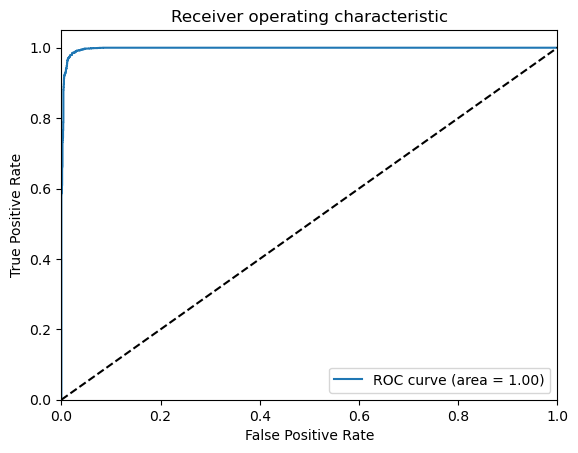

In [55]:
from imblearn.under_sampling import TomekLinks
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from imblearn.combine import SMOTEENN

# Crear un objeto SMOTEENN
smote_enn = SMOTEENN(random_state=42,sampling_strategy="minority")

# Aplicar SMOTEENN al conjunto de datos
X_res, y_res = smote_enn.fit_resample(X, y)

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Entrenar el modelo
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

# Selección de características
selector = SelectFromModel(estimator=clf, prefit=True)
X_train_new = selector.transform(X_train)
X_test_new = selector.transform(X_test)

clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,  # Limitar la profundidad
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
clf.fit(X_train_new, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = clf_new.predict(X_test_new)


# Matriz de confusión
print(confusion_matrix(y_test, y_pred))

# Informe de clasificación
print(classification_report(y_test, y_pred))

# Curva ROC
y_probs = clf.predict_proba(X_test_new)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()

C:\Users\XIMO\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\XIMO\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Características seleccionadas (índices): [ 0  1  2  3  4  6  8  9 12 22]
Matriz de confusión:
 [[2409  325]
 [ 147 2749]]

Informe de clasificación:
               precision    recall  f1-score   support

           0       0.94      0.88      0.91      2734
           1       0.89      0.95      0.92      2896

    accuracy                           0.92      5630
   macro avg       0.92      0.92      0.92      5630
weighted avg       0.92      0.92      0.92      5630

AUC: 0.9770054020983967


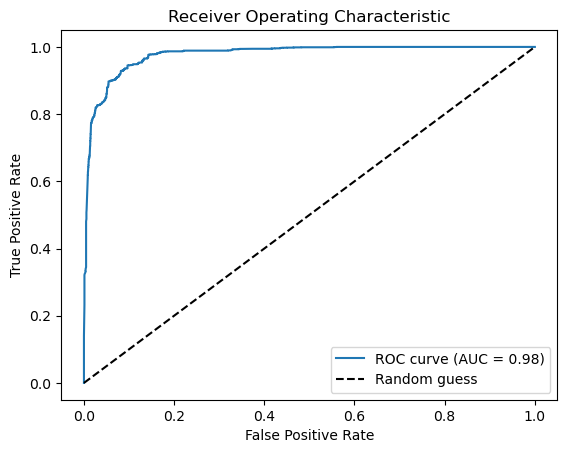

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Entrenar el modelo inicial con XGBoost con máxima regularización
xgb_model = XGBClassifier(
    n_estimators=200,        # Aumentar el número de árboles para compensar la baja tasa de aprendizaje
    max_depth=3,             # Árboles más pequeños
    learning_rate=0.01,      # Tasa de aprendizaje muy baja
    min_child_weight=20,     # Regularización en nodos terminales
    gamma=2.0,               # Penalización para divisiones
    subsample=0.5,           # Usar solo el 50% de las filas
    colsample_bytree=0.5,    # Usar solo el 50% de las columnas
    reg_alpha=1.0,           # Regularización L1 fuerte
    reg_lambda=2.0,          # Regularización L2 fuerte
    random_state=42
)
xgb_model.fit(X_train, y_train)

# Selección de características con SelectFromModel
selector = SelectFromModel(estimator=xgb_model, prefit=True, threshold="mean")
X_train_new = selector.transform(X_train)
X_test_new = selector.transform(X_test)

# Mostrar las características seleccionadas
selected_features = selector.get_support(indices=True)
print("Características seleccionadas (índices):", selected_features)

# Entrenar un nuevo modelo con las características seleccionadas y máxima regularización
xgb_model_new = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.01,
    min_child_weight=20,
    gamma=2.0,
    subsample=0.5,
    colsample_bytree=0.5,
    reg_alpha=1.0,
    reg_lambda=5,
    random_state=42
)
xgb_model_new.fit(X_train_new, y_train)

# Evaluar el nuevo modelo
y_pred = xgb_model_new.predict(X_test_new)
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\nInforme de clasificación:\n", classification_report(y_test, y_pred))

# Curva ROC y AUC
y_pred_prob = xgb_model_new.predict_proba(X_test_new)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc = roc_auc_score(y_test, y_pred_prob)
print("AUC:", auc)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic")
plt.legend(loc="lower right")
plt.show()

# SUBMUESTREO

In [5]:
rows_with_0 = NOAnalizadas[NOAnalizadas['CorregirA1'] == 0]
rows_with_1 = NOAnalizadas[NOAnalizadas['CorregirA1']==1]
final_selection = pd.concat([rows_with_0, rows_with_1])

In [7]:
rows_with_1.head(3)

,Allele 1,Allele 2,Size 1,Size 2,Height 1,Height 2,Peak Area 1,Peak Area 2,Data Point 1,Data Point 2,...,SP,BIN,PHR,LPH,SPU,AN,BD,XTLK,GQ,CorregirA1
148,127.0,NaN,125.91,NaN,1177.0,NaN,7193.0,NaN,2937.0,NaN,...,0.0,0.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.487,1
150,233.0,NaN,231.05,NaN,1193.0,NaN,9363.0,NaN,4261.0,NaN,...,0.0,0.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.487,1
170,149.0,153.0,146.49,150.23,5634.0,6674.0,42347.0,40013.0,3186.0,3233.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.974,1


In [8]:
Analizadas.iloc[148:150,:]

,Allele 1,Allele 2,Size 1,Size 2,Height 1,Height 2,Peak Area 1,Peak Area 2,Data Point 1,Data Point 2,...,SPA,SP,BIN,PHR,LPH,SPU,AN,BD,XTLK,GQ
148,129.0,NaN,128.00,NaN,997.0,NaN,6108.0,NaN,2964.0,NaN,...,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-1.0,-2.0,-2.0,1.0
149,137.0,151.0,134.98,148.21,350.0,298.0,2777.0,2846.0,3037.0,3206.0,...,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-1.0,-2.0,-2.0,1.0


In [118]:
X=final_selection.fillna(-9999)
y=X["CorregirA1"]
X=X.iloc[:,:23]

## Random

In [119]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.feature_selection import SelectFromModel
# Crear el objeto para submuestreo
rus = RandomUnderSampler(random_state=42)

# Aplicar el submuestreo a los datos
X_res, y_res = rus.fit_resample(X, y)

# Ver la distribución de clases después del submuestreo
from collections import Counter
print(Counter(y_res))


Counter({0: 187, 1: 187})


In [120]:
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Entrenar el modelo
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

# Selección de características
selector = SelectFromModel(estimator=clf, prefit=True)
X_train_new = selector.transform(X_train)
X_test_new = selector.transform(X_test)

clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,  # Limitar la profundidad
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
clf.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = clf.predict(X_test)


# Matriz de confusión
print(confusion_matrix(y_test, y_pred))

# Informe de clasificación
print(classification_report(y_test, y_pred))



C:\Users\XIMO\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\XIMO\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


[[35  6]
 [ 4 30]]
              precision    recall  f1-score   support

           0       0.90      0.85      0.88        41
           1       0.83      0.88      0.86        34

    accuracy                           0.87        75
   macro avg       0.87      0.87      0.87        75
weighted avg       0.87      0.87      0.87        75



In [ ]:
y_proba = clf.predict_proba(X_test)[:, 1]


# Calcular la curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Corba ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('1-ESPECIFICITAT',fontsize=20)
plt.ylabel('SENSIBILITAT',fontsize=20)
plt.title('Al·lel 1',fontsize=20)
plt.legend(loc='lower right',fontsize=20)
plt.xticks(fontsize=20)
plt.grid(True, linestyle='--', linewidth=0.5, color='r')
plt.yticks(fontsize=20)
plt.show()

# Calcular la curva Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

# Graficar la curva Precision-Recall
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='red', lw=2, label=f' Corba P-R (AP = {avg_precision:.2f})')
plt.xlabel('SENSIBILITAT',fontsize=20)
plt.ylabel('PRECISIÓ',fontsize=20)
plt.title('Corba Precision-Recall',fontsize=20)
plt.legend(loc='lower left',fontsize=20)
plt.xticks(fontsize=20)
plt.grid(True, linestyle='--', linewidth=0.5, color='r')
plt.yticks(fontsize=20)
plt.show()


## TomekLinks

In [10]:
from imblearn.under_sampling import TomekLinks
from sklearn.feature_selection import SelectFromModel
# Crear el objeto TomekLinks
tomek = TomekLinks()

# Aplicar TomekLinks para submuestreo
X_res, y_res = tomek.fit_resample(X, y)

# Comprobar la distribución de clases
from collections import Counter
print(Counter(y_res))


Counter({1: 15292, 0: 187})


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Entrenar el modelo
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

# Selección de características
selector = SelectFromModel(estimator=clf, prefit=True)
X_train_new = selector.transform(X_train)
X_test_new = selector.transform(X_test)

clfbo = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,  # Limitar la profundidad
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight="balanced_subsample"
    
)
clfbo.fit(X_train_new, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = clfbo.predict(X_test_new)


# Matriz de confusión
print(confusion_matrix(y_test, y_pred))

# Informe de clasificación
print(classification_report(y_test, y_pred))



C:\Users\XIMO\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\XIMO\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


[[  29   16]
 [  15 3036]]
              precision    recall  f1-score   support

           0       0.66      0.64      0.65        45
           1       0.99      1.00      0.99      3051

    accuracy                           0.99      3096
   macro avg       0.83      0.82      0.82      3096
weighted avg       0.99      0.99      0.99      3096



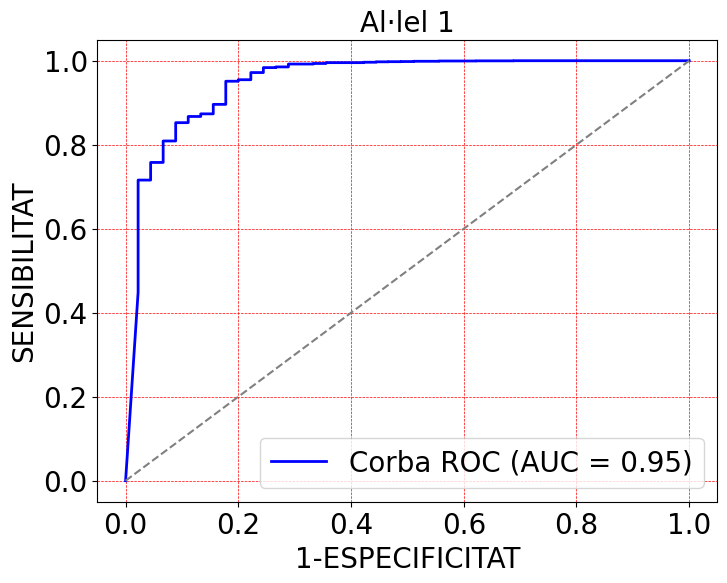

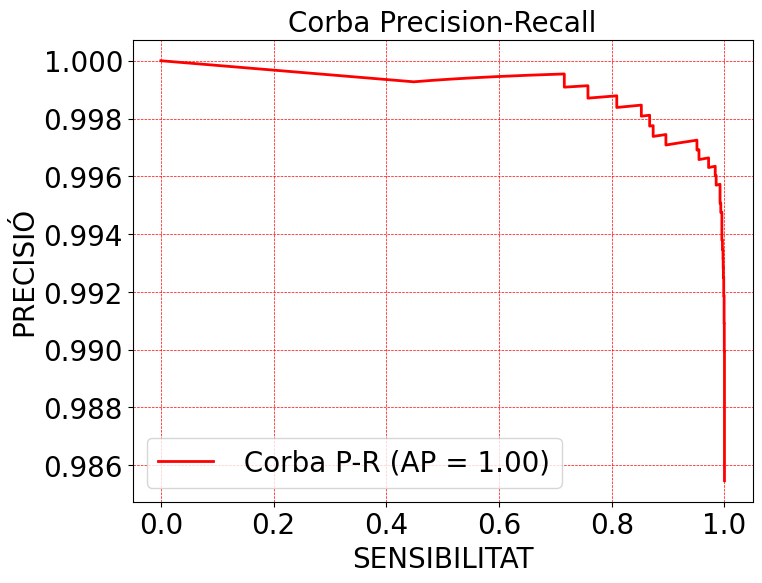

In [12]:
y_proba = clfbo.predict_proba(X_test_new)[:, 1]


# Calcular la curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Corba ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('1-ESPECIFICITAT',fontsize=20)
plt.ylabel('SENSIBILITAT',fontsize=20)
plt.title('Al·lel 1',fontsize=20)
plt.legend(loc='lower right',fontsize=20)
plt.xticks(fontsize=20)
plt.grid(True, linestyle='--', linewidth=0.5, color='r')
plt.yticks(fontsize=20)
plt.show()

# Calcular la curva Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

# Graficar la curva Precision-Recall
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='red', lw=2, label=f' Corba P-R (AP = {avg_precision:.2f})')
plt.xlabel('SENSIBILITAT',fontsize=20)
plt.ylabel('PRECISIÓ',fontsize=20)
plt.title('Corba Precision-Recall',fontsize=20)
plt.legend(loc='lower left',fontsize=20)
plt.xticks(fontsize=20)
plt.grid(True, linestyle='--', linewidth=0.5, color='r')
plt.yticks(fontsize=20)
plt.show()

## ClusterCentroids

In [13]:
from imblearn.under_sampling import ClusterCentroids
from collections import Counter

# Crear el objeto ClusterCentroids
cluster = ClusterCentroids(random_state=42)

# Aplicar ClusterCentroids
X_res, y_res = cluster.fit_resample(X, y)

# Comprobar la distribución de clases
print(Counter(y_res))

C:\Users\XIMO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Counter({0: 187, 1: 187})


In [14]:
from sklearn.feature_selection import SelectFromModel
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Entrenar el modelo
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

# Selección de características
selector = SelectFromModel(estimator=clf, prefit=True)
X_train_new = selector.transform(X_train)
X_test_new = selector.transform(X_test)

clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,  # Limitar la profundidad
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight="balanced_subsample"
    
)
clf.fit(X_train_new, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = clf.predict(X_test_new)


# Matriz de confusión
print(confusion_matrix(y_test, y_pred))

# Informe de clasificación
print(classification_report(y_test, y_pred))



C:\Users\XIMO\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\XIMO\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


[[40  1]
 [ 3 31]]
              precision    recall  f1-score   support

           0       0.93      0.98      0.95        41
           1       0.97      0.91      0.94        34

    accuracy                           0.95        75
   macro avg       0.95      0.94      0.95        75
weighted avg       0.95      0.95      0.95        75



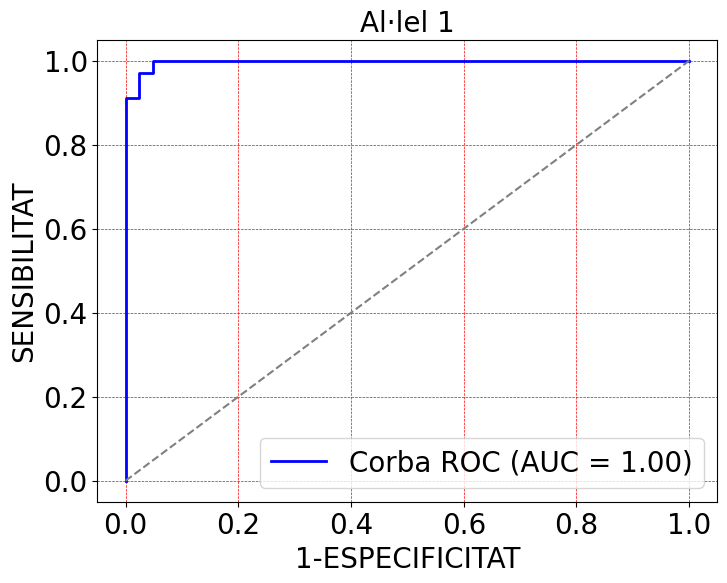

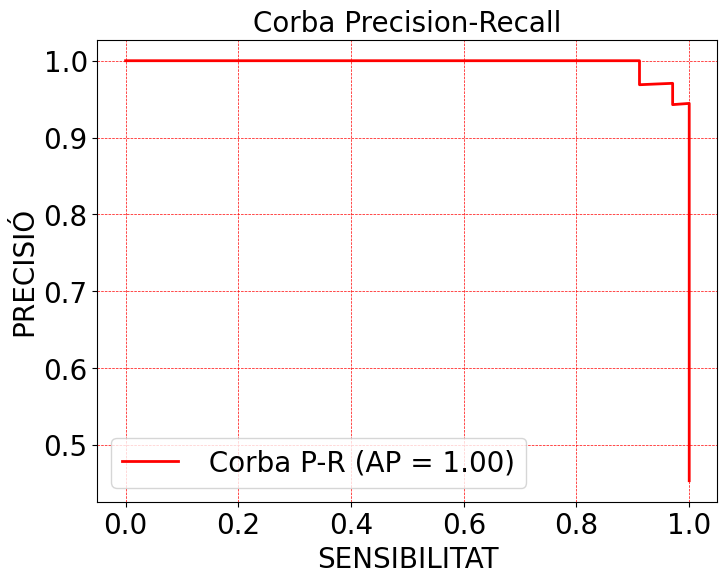

In [15]:
y_proba = clf.predict_proba(X_test_new)[:, 1]


# Calcular la curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Corba ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('1-ESPECIFICITAT',fontsize=20)
plt.ylabel('SENSIBILITAT',fontsize=20)
plt.title('Al·lel 1',fontsize=20)
plt.legend(loc='lower right',fontsize=20)
plt.xticks(fontsize=20)
plt.grid(True, linestyle='--', linewidth=0.5, color='r')
plt.yticks(fontsize=20)
plt.show()

# Calcular la curva Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

# Graficar la curva Precision-Recall
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='red', lw=2, label=f' Corba P-R (AP = {avg_precision:.2f})')
plt.xlabel('SENSIBILITAT',fontsize=20)
plt.ylabel('PRECISIÓ',fontsize=20)
plt.title('Corba Precision-Recall',fontsize=20)
plt.legend(loc='lower left',fontsize=20)
plt.xticks(fontsize=20)
plt.grid(True, linestyle='--', linewidth=0.5, color='r')
plt.yticks(fontsize=20)
plt.show()

## ENN

In [65]:
from imblearn.under_sampling import EditedNearestNeighbours

# Crear el objeto ENN
enn = EditedNearestNeighbours(n_neighbors=80)

# Aplicar ENN
X_res, y_res = enn.fit_resample(X, y)

# Comprobar la distribución de clases
print(Counter(y_res))


Counter({0: 10766, 1: 187})


In [66]:
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Entrenar el modelo
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

# Selección de características
selector = SelectFromModel(estimator=clf, prefit=True)
X_train_new = selector.transform(X_train)
X_test_new = selector.transform(X_test)

clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,  # Limitar la profundidad
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight="balanced_subsample"
    
)
clf.fit(X_train_new, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = clf.predict(X_test_new)


# Matriz de confusión
print(confusion_matrix(y_test, y_pred))

# Informe de clasificación
print(classification_report(y_test, y_pred))


C:\Users\XIMO\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\XIMO\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


[[2143    4]
 [   6   38]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2147
           1       0.90      0.86      0.88        44

    accuracy                           1.00      2191
   macro avg       0.95      0.93      0.94      2191
weighted avg       1.00      1.00      1.00      2191



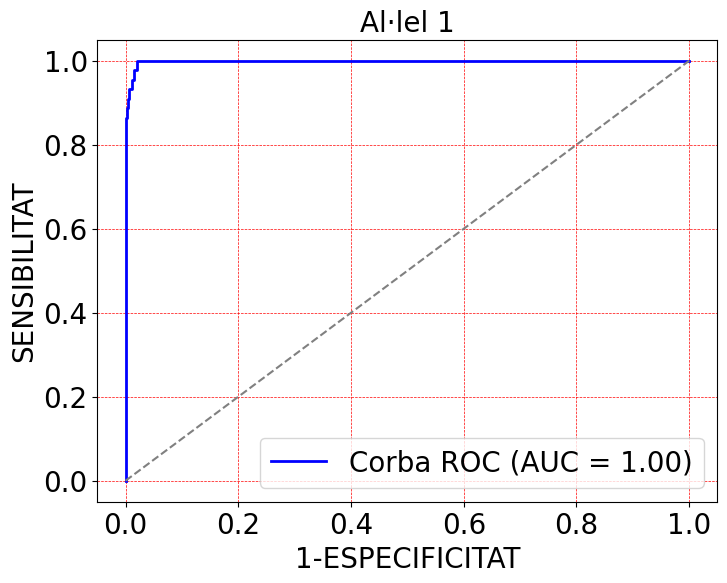

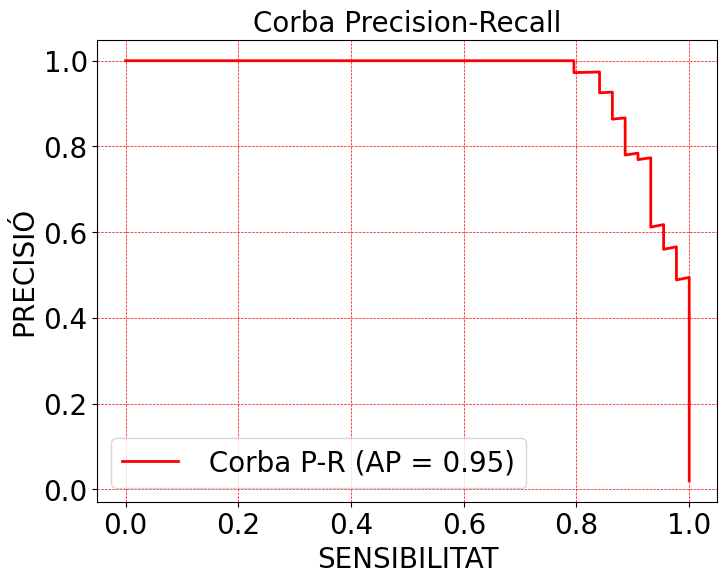

In [98]:
y_proba = clf.predict_proba(X_test_new)[:, 1]


# Calcular la curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Corba ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('1-ESPECIFICITAT',fontsize=20)
plt.ylabel('SENSIBILITAT',fontsize=20)
plt.title('Al·lel 1',fontsize=20)
plt.legend(loc='lower right',fontsize=20)
plt.xticks(fontsize=20)
plt.grid(True, linestyle='--', linewidth=0.5, color='r')
plt.yticks(fontsize=20)
plt.show()

# Calcular la curva Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

# Graficar la curva Precision-Recall
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='red', lw=2, label=f' Corba P-R (AP = {avg_precision:.2f})')
plt.xlabel('SENSIBILITAT',fontsize=20)
plt.ylabel('PRECISIÓ',fontsize=20)
plt.title('Corba Precision-Recall',fontsize=20)
plt.legend(loc='lower left',fontsize=20)
plt.xticks(fontsize=20)
plt.grid(True, linestyle='--', linewidth=0.5, color='r')
plt.yticks(fontsize=20)
plt.show()

## NearMiss

In [99]:
from imblearn.under_sampling import NearMiss
from collections import Counter

# Aplicar NearMiss para submuestreo
nearmiss = NearMiss(version=3, n_neighbors=3)
X_res, y_res = nearmiss.fit_resample(X, y)

print("Distribución de clases después de NearMiss:", Counter(y_res))

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Modelo con parámetros ajustados
clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,  # Limitar la profundidad
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight="balanced"  # Penalizar desequilibrio
)
clf.fit(X_train, y_train)

# Predicciones y evaluación
y_pred = clf.predict(X_test)

# Evaluar modelo
print("Matriz de Confusión:\n", confusion_matrix(y_test, y_pred))
print("Informe de Clasificación:\n", classification_report(y_test, y_pred))


Distribución de clases después de NearMiss: Counter({0: 187, 1: 187})
Matriz de Confusión:
 [[39  2]
 [ 5 29]]
Informe de Clasificación:
               precision    recall  f1-score   support

           0       0.89      0.95      0.92        41
           1       0.94      0.85      0.89        34

    accuracy                           0.91        75
   macro avg       0.91      0.90      0.90        75
weighted avg       0.91      0.91      0.91        75



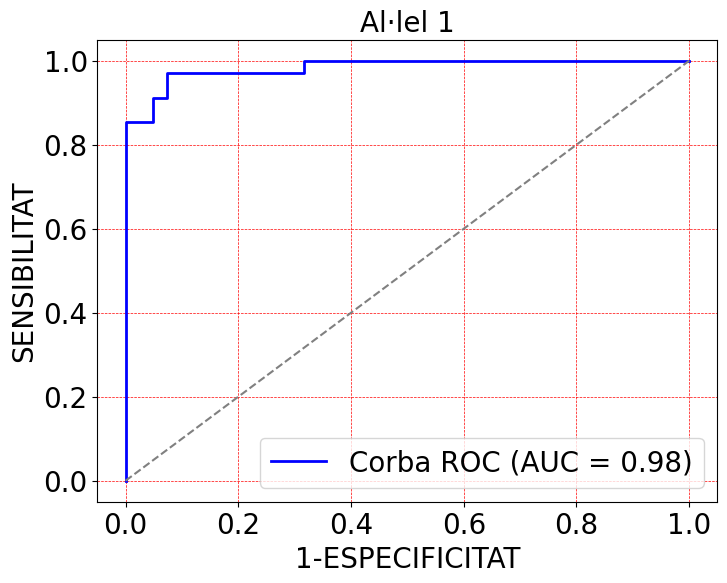

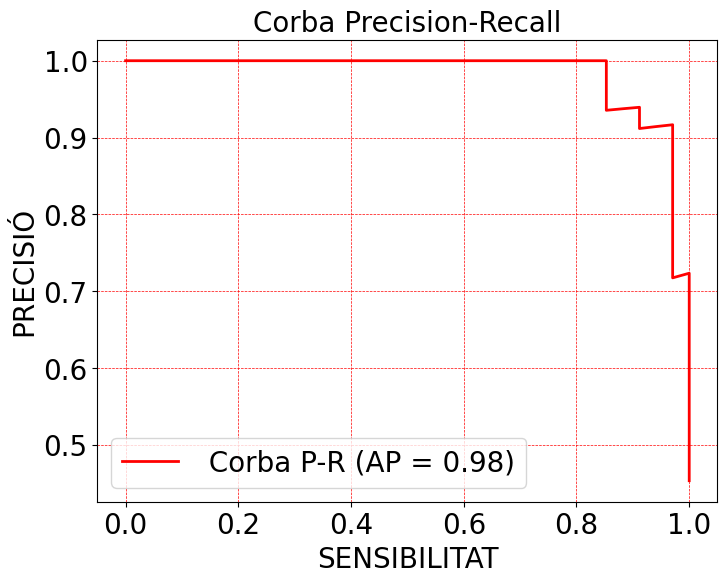

In [101]:
y_proba = clf.predict_proba(X_test)[:, 1]


# Calcular la curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Corba ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('1-ESPECIFICITAT',fontsize=20)
plt.ylabel('SENSIBILITAT',fontsize=20)
plt.title('Al·lel 1',fontsize=20)
plt.legend(loc='lower right',fontsize=20)
plt.xticks(fontsize=20)
plt.grid(True, linestyle='--', linewidth=0.5, color='r')
plt.yticks(fontsize=20)
plt.show()

# Calcular la curva Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

# Graficar la curva Precision-Recall
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='red', lw=2, label=f' Corba P-R (AP = {avg_precision:.2f})')
plt.xlabel('SENSIBILITAT',fontsize=20)
plt.ylabel('PRECISIÓ',fontsize=20)
plt.title('Corba Precision-Recall',fontsize=20)
plt.legend(loc='lower left',fontsize=20)
plt.xticks(fontsize=20)
plt.grid(True, linestyle='--', linewidth=0.5, color='r')
plt.yticks(fontsize=20)
plt.show()

# Regressor

In [9]:
def accuracy(y_true, y_pred):
    y_pred_redondeado = np.round(y_pred)
    
    y_true = np.array(y_true)
    y_pred_redondeado = np.array(y_pred_redondeado)
    
    # Comparar los valores
    aciertos = np.sum(y_pred_redondeado == y_true)
    
    # Calcular la precisión
    precision = aciertos / len(y_true)
    return precision


In [10]:
X=NOAnalizadas[NOAnalizadas['CorregirA1']==1].fillna(-9999)
Analizadas_filtradas = Analizadas.loc[X.index]
y=Analizadas_filtradas["Allele 1"]
X = X.drop(columns=["CorregirA1","Allele 1"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

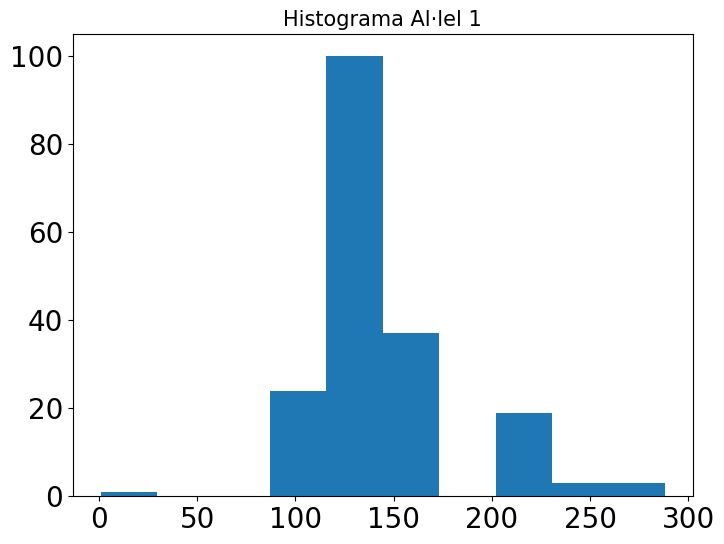

In [12]:
plt.figure(figsize=(8, 6))
plt.hist(y,bins=10)
plt.title('Histograma Al·lel 1',fontsize=15)
plt.tick_params(axis='both', labelsize=20)
plt.show()

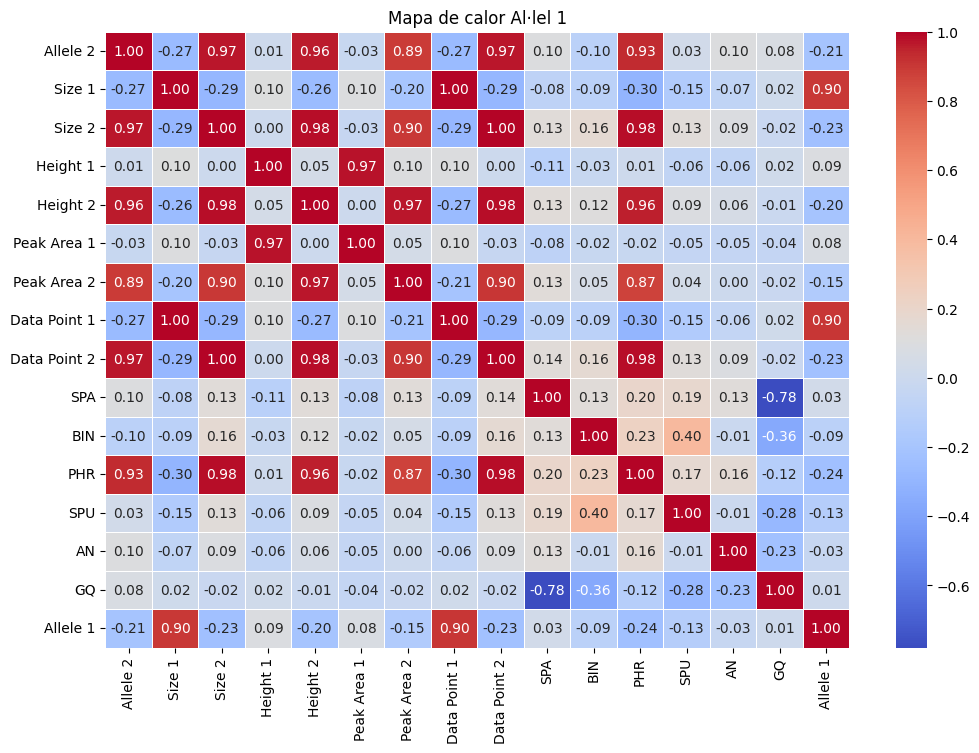

In [13]:
drop=X.drop(["OS","SHP","OBA","SP","LPH","BD","XTLK"], axis=1)
df = pd.concat([drop, y], axis=1)
# Calcular la matriz de correlación
corr_matrix = df.corr()
# Graficar el heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Mapa de calor Al·lel 1")
plt.show()

In [85]:
# X = X.drop(columns=["Allele 1","Size 1"])
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Permutation Importance

In [1]:
from sklearn.inspection import permutation_importance
# Entrenar un modelo de regresión
modelo = RandomForestRegressor(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# Definir la métrica personalizada
def custom_accuracy(model, X, y):
    y_pred = model.predict(X)
    y_pred_redondeado = np.round(y_pred)  # Redondear predicciones
    aciertos = np.sum(y_pred_redondeado == y)  # Contar aciertos
    return aciertos / len(y)  # Accuracy

# Aplicar Permutation Importance
resultados = permutation_importance(
    modelo, X_test, y_test, scoring=custom_accuracy, n_repeats=10, random_state=42
)

# Seleccionar las mejores características (las 3 más importantes, por ejemplo)
num_features = 1
top_features_idx = np.argsort(resultados.importances_mean)[-num_features:]  # Índices de las mejores características

# Reducir el dataset a solo esas características
X_train_reducido = X_train.iloc[:, top_features_idx]
X_test_reducido = X_test.iloc[:, top_features_idx]

importancias = resultados.importances_mean
errores = resultados.importances_std
features = X_test.columns

# Ordenar por importancia
indices = np.argsort(importancias)[::-1]

# Graficar
plt.figure(figsize=(10, 6))
sns.barplot(x=importancias[indices], y=np.array(features)[indices], xerr=errores[indices], palette="viridis")
plt.xlabel("Importància per permutació")
plt.ylabel("Característiques")
plt.title("Importància de les Característiques (Permutation Importance)")
plt.show()

NameError: name 'RandomForestRegressor' is not defined

In [75]:
modelo_reducido = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_reducido.fit(X_train_reducido, y_train)

# Evaluar ambos modelos
y_pred_original = np.round(modelo.predict(X_test))  # Modelo con todas las features
accuracy_original = np.sum(y_pred_original == y_test) / len(y_test)

y_pred_reducido = np.round(modelo_reducido.predict(X_test_reducido))  # Modelo reducido
accuracy_reducido = np.sum(y_pred_reducido == y_test) / len(y_test)

# Comparación de resultados
print(f"Accuracy modelo original: {accuracy_original:.4f}")
print(f"Accuracy modelo reducido: {accuracy_reducido:.4f}")

Accuracy modelo original: 0.5000
Accuracy modelo reducido: 0.5526


## PCA

Varianza explicada por cada componente: [0.32037283 0.1729918  0.14190492 0.10606368 0.09314548 0.06030547]
Varianza total explicada por las 6 primeras componentes: 0.89


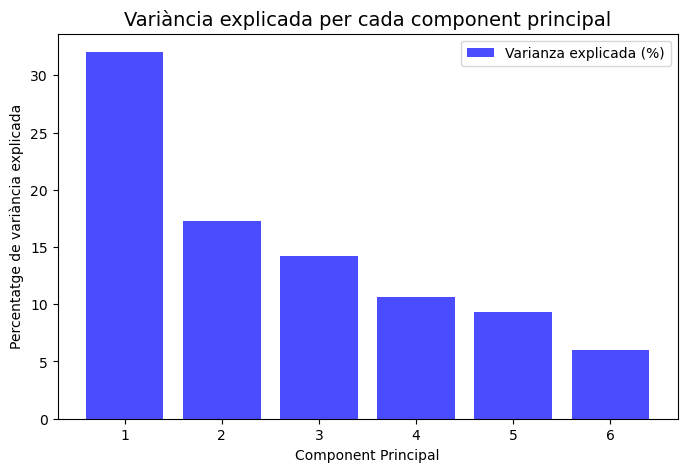

In [76]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# Estandarizar los datos antes de aplicar PCA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Aplicar PCA
k = 6  # Número de componentes principales deseadas
pca = PCA(n_components=k)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Entrenar el modelo con las componentes principales
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_pca, y_train)

# Obtener la varianza explicada por cada componente
explained_variance = pca.explained_variance_ratio_
print(f"Varianza explicada por cada componente: {explained_variance}")
print(f"Varianza total explicada por las {k} primeras componentes: {sum(explained_variance):.2f}")

# Visualizar la importancia de cada componente principal
plt.figure(figsize=(8, 5))
plt.bar(range(1, k + 1), explained_variance * 100, alpha=0.7, color='b', label="Varianza explicada (%)")
plt.xlabel('Component Principal')
plt.ylabel('Percentatge de variància explicada')
plt.title('Variància explicada per cada component principal', fontsize=14)
plt.legend()
plt.show()


## SelectKBest

C:\Users\ENTRA\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\ENTRA\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


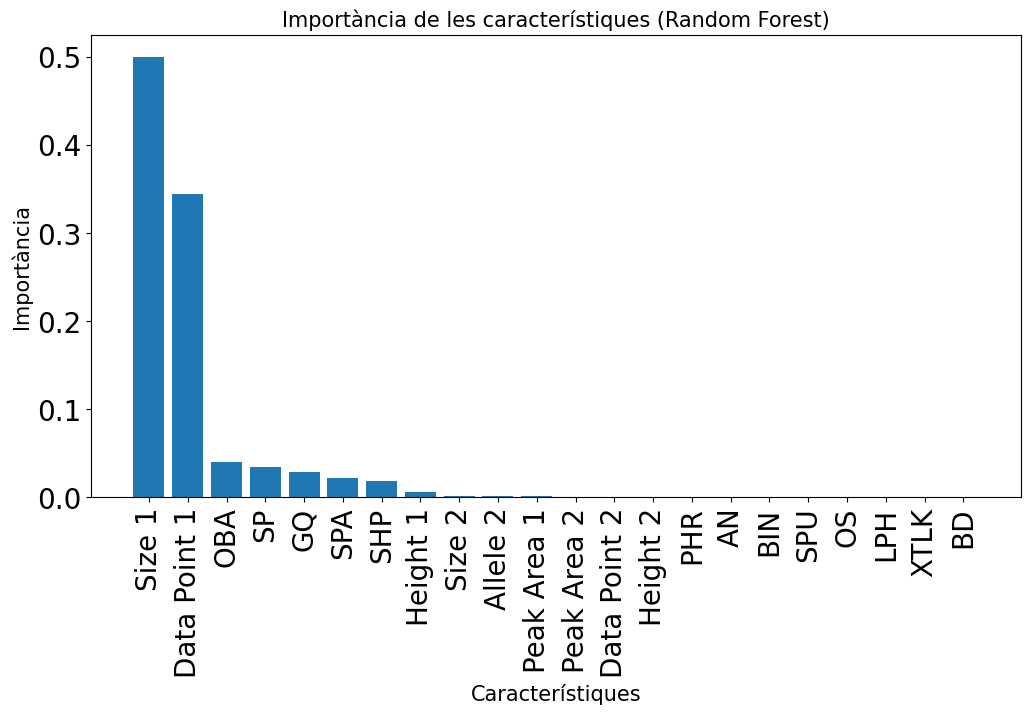

In [20]:
from sklearn.feature_selection import SelectFromModel
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Seleccionar características importantes
selector = SelectFromModel(model, max_features=1,prefit=True)
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

# Obtener los nombres de las características seleccionadas
mask = selector.get_support()
best_feature_names = X.columns[mask]

# Obtener la importancia de las características
importances = model.feature_importances_
sorted_indices = np.argsort(importances)[::-1]  # Ordenar por importancia descendente

# Visualizar la importancia de las características
plt.figure(figsize=(12, 6))
plt.title("Importància de les característiques (Random Forest)", fontsize=15)
plt.bar(range(len(importances)), importances[sorted_indices], align="center")
plt.xticks(range(len(importances)), X.columns[sorted_indices], rotation=90, fontsize=15)
plt.xlabel("Característiques", fontsize=15)
plt.ylabel("Importància", fontsize=15)
plt.tick_params(axis="both", labelsize=20)
plt.show()


# Models

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
model = LinearRegression()
model.fit(X_train_selected, y_train)

y_pred = model.predict(X_test_selected)
r2 = r2_score(y_test, y_pred)
print(f'R^2 Score: {r2:.2f}')

y_pred_redondeado = np.round(y_pred)
aciertos = np.sum(y_pred_redondeado == y_test)
accuracy = aciertos / len(y_test)

print(f'Accuracy del regresor: {accuracy*100:.2f}%')
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))

R^2 Score: 0.94
Accuracy del regresor: 5.26%
RMSE: 9.193502765885162


In [22]:
rf = RandomForestRegressor(random_state=42)

# Ajustar el modelo en los datos de entrenamiento
rf.fit(X_train_selected, y_train)
y_pred = rf.predict(X_test_selected)
y_pred_redondeado = np.round(y_pred)
aciertos = np.sum(y_pred_redondeado == y_test)
accuracy = aciertos / len(y_test)

print(f'Accuracy del regresor: {accuracy*100:.2f}%')
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))

Accuracy del regresor: 55.26%
RMSE: 6.940372453224226


In [89]:
from sklearn.svm import SVR
model = SVR()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f'R^2 Score: {r2:.2f}')

y_pred_redondeado = np.round(y_pred)
aciertos = np.sum(y_pred_redondeado == y_test)
accuracy = aciertos / len(y_test)

print(f'Accuracy del regresor: {accuracy*100:.2f}%')
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))

R^2 Score: -0.15
Accuracy del regresor: 2.63%
RMSE: 39.89546538760964


In [92]:
from sklearn.ensemble import ExtraTreesRegressor
model = ExtraTreesRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f'R^2 Score: {r2:.2f}')

y_pred_redondeado = np.round(y_pred)
aciertos = np.sum(y_pred_redondeado == y_test)
accuracy = aciertos / len(y_test)

print(f'Accuracy del regresor: {accuracy*100:.2f}%')
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))

R^2 Score: 0.99
Accuracy del regresor: 50.00%
RMSE: 4.2137288149946


In [95]:
from lightgbm import LGBMRegressor
model = LGBMRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f'R^2 Score: {r2:.2f}')

y_pred_redondeado = np.round(y_pred)
aciertos = np.sum(y_pred_redondeado == y_test)
accuracy = aciertos / len(y_test)

print(f'Accuracy del regresor: {accuracy*100:.2f}%')
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000108 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 314
[LightGBM] [Info] Number of data points in the train set: 149, number of used features: 12
[LightGBM] [Info] Start training from score 140.859060
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

In [111]:
from xgboost import XGBRegressor
model = XGBRegressor(random_state=42)
model.fit(X_train_reducido, y_train)

y_pred = model.predict(X_test_reducido)
r2 = r2_score(y_test, y_pred)
print(f'R^2 Score: {r2:.2f}')

y_pred_redondeado = np.round(y_pred)
aciertos = np.sum(y_pred_redondeado == y_test)
accuracy = aciertos / len(y_test)

print(f'Accuracy del regresor: {accuracy*100:.2f}%')
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))

R^2 Score: 0.97
Accuracy del regresor: 55.26%
RMSE: 6.960311115062121


In [102]:
import optuna
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Definir la función objetivo para Optuna

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.2),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 1),
        'random_state': 42
    }
    
    model = XGBRegressor(**params)
    model.fit(X_train_reducido , y_train)
    y_pred = model.predict(X_test_reducido)
    y_pred_redondeado = np.round(y_pred)
    accuracy = np.sum(y_pred_redondeado == y_test) / len(y_test)

    return accuracy

# Crear el estudio y optimizar
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=300, n_jobs=-1)

# Mejor conjunto de hiperparámetros
best_params = study.best_params
print("Mejores hiperparámetros:", best_params)

# Entrenar modelo final con los mejores parámetros
best_model = XGBRegressor(**best_params)
best_model.fit(X_train_selected, y_train)

y_pred = best_model.predict(X_test_selected)
r2 = r2_score(y_test, y_pred)
print(f'R^2 Score: {r2:.2f}')

y_pred_redondeado = np.round(y_pred)
aciertos = np.sum(y_pred_redondeado == y_test)
accuracy = aciertos / len(y_test)

print(f'Accuracy del regresor: {accuracy*100:.2f}%')
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))


[I 2025-03-14 15:36:39,672] A new study created in memory with name: no-name-0b167283-1c17-4c55-8e6c-fd17ea9d78aa
[I 2025-03-14 15:36:39,876] Trial 7 finished with value: 0.15789473684210525 and parameters: {'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.10571430817503397, 'subsample': 0.7437402800072056, 'colsample_bytree': 0.8406069315060216, 'reg_alpha': 0.7663994773139331, 'reg_lambda': 0.7587231287232923}. Best is trial 7 with value: 0.15789473684210525.
[I 2025-03-14 15:36:39,897] Trial 6 finished with value: 0.21052631578947367 and parameters: {'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.08035290890796379, 'subsample': 0.9271466247148104, 'colsample_bytree': 0.9416172945162173, 'reg_alpha': 0.5876883620338913, 'reg_lambda': 0.5016631995351379}. Best is trial 6 with value: 0.21052631578947367.
[I 2025-03-14 15:36:40,066] Trial 8 finished with value: 0.18421052631578946 and parameters: {'n_estimators': 50, 'max_depth': 6, 'learning_rate': 0.07231549821609244, 's

Mejores hiperparámetros: {'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.18525625692052086, 'subsample': 0.8583475764614452, 'colsample_bytree': 0.9860835488457491, 'reg_alpha': 0.6308763841791833, 'reg_lambda': 0.08303724454999425}
R^2 Score: 0.98
Accuracy del regresor: 34.21%
RMSE: 5.211242077479752


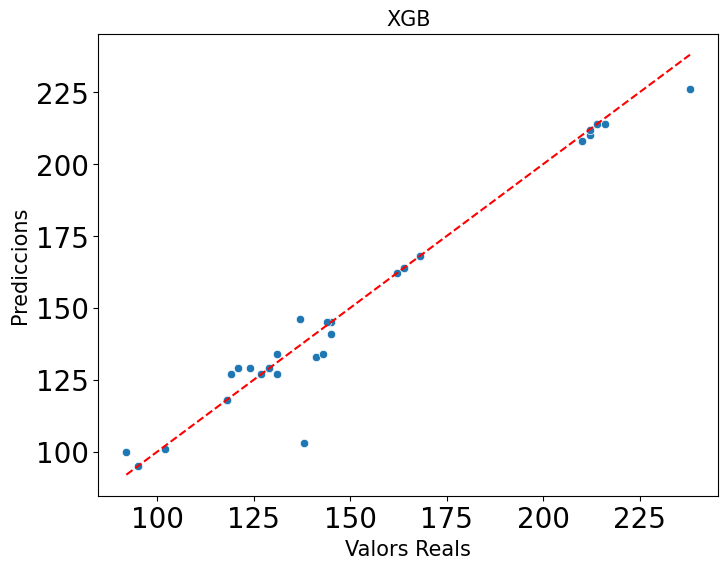

In [112]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_redondeado)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')  # Línea y=x
plt.xlabel('Valors Reals',fontsize=15)
plt.ylabel('Prediccions',fontsize=15)
plt.title('XGB',fontsize=15)
plt.tick_params(axis='both', labelsize=20)
plt.show()

In [113]:
y_test

15805    214.0
6170     168.0
4390     129.0
10072    216.0
13511    118.0
1000     212.0
6044     164.0
12419    118.0
8032      95.0
14927    162.0
13163    168.0
3024      92.0
13777    131.0
1532     145.0
4097     145.0
1051     127.0
13829    138.0
15280    214.0
6491     141.0
1147     212.0
8114     118.0
7724     164.0
275      137.0
11705    124.0
1261     119.0
12377    118.0
568      129.0
10333    129.0
9693     144.0
13616    118.0
1138     238.0
14818    210.0
6065     168.0
5483     131.0
5525     143.0
1995     102.0
6947     168.0
11404    121.0
Name: Allele 1, dtype: float64

In [114]:
y_pred_redondeado

array([214., 168., 129., 214., 118., 210., 164., 118.,  95., 162., 168.,
       100., 127., 145., 141., 127., 103., 214., 133., 212., 118., 164.,
       146., 129., 127., 118., 129., 129., 145., 118., 226., 208., 168.,
       134., 134., 101., 168., 129.], dtype=float32)